# Customer Churn & Retention Analysis

In [1]:
from insightfulpy.eda import *
from insightfulpy.eda import columns_info, missing_inf_values, detect_mixed_data_types
from scipy import stats
from scipy.stats import mannwhitneyu
import logging
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
import warnings

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

print("Imports successful!")

warnings.filterwarnings("ignore")
logging.getLogger("matplotlib").setLevel(logging.WARNING)

Imports successful!


## 1. Load Data

In [2]:
data_dir = r"output/raw"

# Load SQL data
customers = pd.read_csv(os.path.join(data_dir, "customers.csv"))
subscriptions = pd.read_csv(os.path.join(data_dir, "subscriptions.csv"))
support_tickets = pd.read_csv(os.path.join(data_dir, "support_tickets.csv"))
plans = pd.read_csv(os.path.join(data_dir, "plans.csv"))

# Load MongoDB data
activity = pd.read_csv(os.path.join(data_dir, "activity_clean.csv"))
nps = pd.read_csv(os.path.join(data_dir, "nps.csv"))

print(f"Loaded SQL data: {len(customers)} customers, {len(subscriptions)} subscriptions")
print(f"Loaded Mongo data: {len(activity)} activity logs")

Loaded SQL data: 1204 customers, 1840 subscriptions
Loaded Mongo data: 99970 activity logs


In [3]:
print("--- FULL PROFILING: SQL CUSTOMERS (Before Cleaning) ---")
analyze_data(customers)

--- FULL PROFILING: SQL CUSTOMERS (Before Cleaning) ---




=== Numerical Analysis ===
|    | Variable    |    N |     Mean |       SD |      SE |   95% Conf. |   Interval |
|---:|:------------|-----:|---------:|---------:|--------:|------------:|-----------:|
|  0 | customer_id | 1204 | 602.5    | 347.709  | 10.0208 |    582.84   |   622.16   |
|  1 | nps_score   |  716 |   6.0601 |   2.9533 |  0.1104 |      5.8434 |     6.2767 |

=== Categorical Analysis ===


|      | Variable      | Outcome                              |   Count |   Percent |
|-----:|:--------------|:-------------------------------------|--------:|----------:|
|    0 | company_name  | AcmeLabs                             |       2 |      0.17 |
|    1 | company_name  | Wave Group                           |       1 |      0.08 |
|    2 | company_name  | QuestAnalytics                       |       1 |      0.08 |
|    3 | company_name  | RiftWorks                            |       1 |      0.08 |
|    4 | company_name  | PeakIO                               |       1 |      0.08 |
|    5 | company_name  | Data Systems                         |       1 |      0.08 |
|    6 | company_name  | Iris Hub                             |       1 |      0.08 |
|    7 | company_name  | GlowSystems                          |       1 |      0.08 |
|    8 | company_name  | Xenon Cloud                          |       1 |      0.08 |
|    9 | company_name  | QuarkDev                     

In [4]:
print("\n--- FULL PROFILING: SQL SUBSCRIPTIONS (Before Cleaning) ---")
analyze_data(subscriptions)


--- FULL PROFILING: SQL SUBSCRIPTIONS (Before Cleaning) ---










=== Numerical Analysis ===
|    | Variable        |    N |     Mean |       SD |      SE |   95% Conf. |   Interval |
|---:|:----------------|-----:|---------:|---------:|--------:|------------:|-----------:|
|  0 | subscription_id | 1840 | 920.5    | 531.307  | 12.3861 |    896.208  |   944.792  |
|  1 | customer_id     | 1840 | 602.67   | 341.613  |  7.9639 |    587.051  |   618.289  |
|  2 | plan_id         | 1840 |   3.0772 |   1.7195 |  0.0401 |      2.9986 |     3.1558 |
|  3 | mrr_usd         | 1840 |  28.8254 |  34.008  |  0.7928 |     27.2705 |    30.3803 |
|  4 | discount_pct    | 1840 |   3.0136 |   6.6659 |  0.1554 |      2.7088 |     3.3184 |

=== Categorical Analysis ===
|      | Variable            | Outcome                    |   Count |   Percent |
|-----:|:--------------------|:---------------------------|--------:|----------:|
|    0 | status              | active                     |     914 |  

In [5]:
print("\n--- FULL PROFILING: MONGODB ACTIVITY LOGS (Before Cleaning) ---")
columns_info("Activity Logs", activity)
missing_inf_values(activity)
detect_mixed_data_types(activity)


--- FULL PROFILING: MONGODB ACTIVITY LOGS (Before Cleaning) ---

======== Activity Logs: ===========

Index Col Index  Attribute                      Data Type       Range                          Distinct Count
----- ---------- ------------------------------ --------------- ------------------------------ ---------------
1     0          customer_id                    float64         1.0 - 9995.0                   1721


2     1          member_id                      float64         1.0 - 99981.0                  8804
3     5          session_duration_sec           float64         30.0 - 3600.0                  3571
4     11         userId                         float64         1.0 - 99981.0                  6678
5     12         customerId                     float64         1.0 - 9988.0                   1404
6     15         userID                         float64         2.0 - 99965.0                  5081
7     2          timestamp                      object          N/A                            50807
8     3          event_type                     object          N/A                            14
9     4          page_url                       object          N/A                            2731
10    6          browser                        object          N/A                            6
11    7          os                             object          N/A                            7
12    8


Infinite Values Summary:
No infinite values found.


'No mixed data types detected!'

--- SQL DATA: ADVANCED PRE-CLEANING VISUALIZATIONS ---


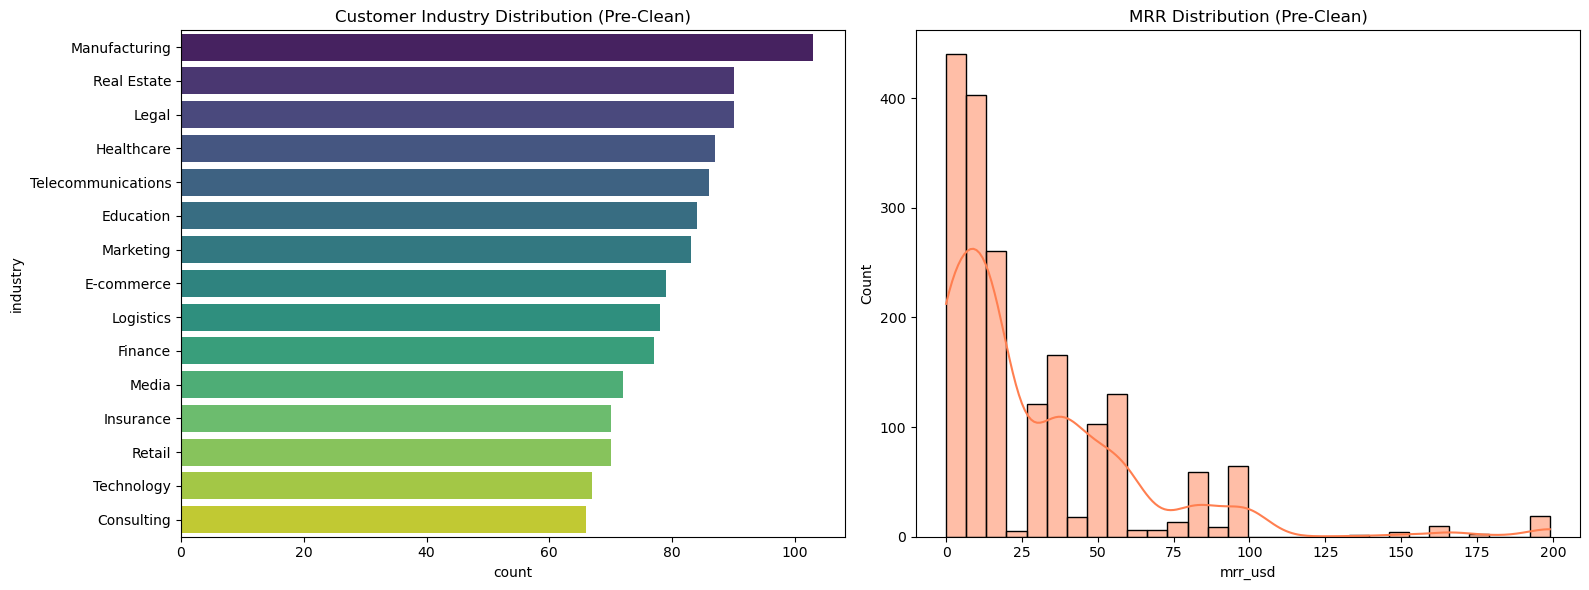

In [6]:
print("--- SQL DATA: ADVANCED PRE-CLEANING VISUALIZATIONS ---")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Customers: Industry Distribution
sns.countplot(data=customers, y='industry', order=customers['industry'].value_counts().index, ax=axes[0], palette='viridis')
axes[0].set_title("Customer Industry Distribution (Pre-Clean)")

# 2. Subscriptions: MRR Distribution with KDE
sns.histplot(data=subscriptions, x='mrr_usd', kde=True, bins=30, ax=axes[1], color='coral')
axes[1].set_title("MRR Distribution (Pre-Clean)")

plt.tight_layout()
plt.show()

# Advanced SQL Stats

In [7]:
print("\n--- SQL Data Statistical Overview ---")
mrr_skew = stats.skew(subscriptions['mrr_usd'].dropna())
mrr_kurtosis = stats.kurtosis(subscriptions['mrr_usd'].dropna())
print(f"MRR Skewness: {mrr_skew:.2f} | MRR Kurtosis: {mrr_kurtosis:.2f}")


--- SQL Data Statistical Overview ---
MRR Skewness: 2.22 | MRR Kurtosis: 6.83


In [8]:
print("\n--- InsightfulPy: SQL Data Overview ---")

columns_info("Customers", customers)
missing_inf_values(customers)
columns_info("Subscriptions", subscriptions)
missing_inf_values(subscriptions)
columns_info("Support Tickets", support_tickets)
missing_inf_values(support_tickets)
columns_info("Plans", plans)
missing_inf_values(plans)


--- InsightfulPy: SQL Data Overview ---

======== Customers: ===========

Index Col Index  Attribute                      Data Type       Range                          Distinct Count
----- ---------- ------------------------------ --------------- ------------------------------ ---------------
1     11         is_active                      bool            N/A                            2
2     14         nps_score                      float64         0.0 - 10.0                     11
3     0          customer_id                    int64           1 - 1204                       1204
4     1          company_name                   object          N/A                            1202
5     2          industry                       object          N/A                            15
6     3          company_size                   object          N/A                            4
7     4          country_code                   object          N/A                            10
8     5         

--- MONGODB DATA: ADVANCED PRE-CLEANING VISUALIZATIONS ---


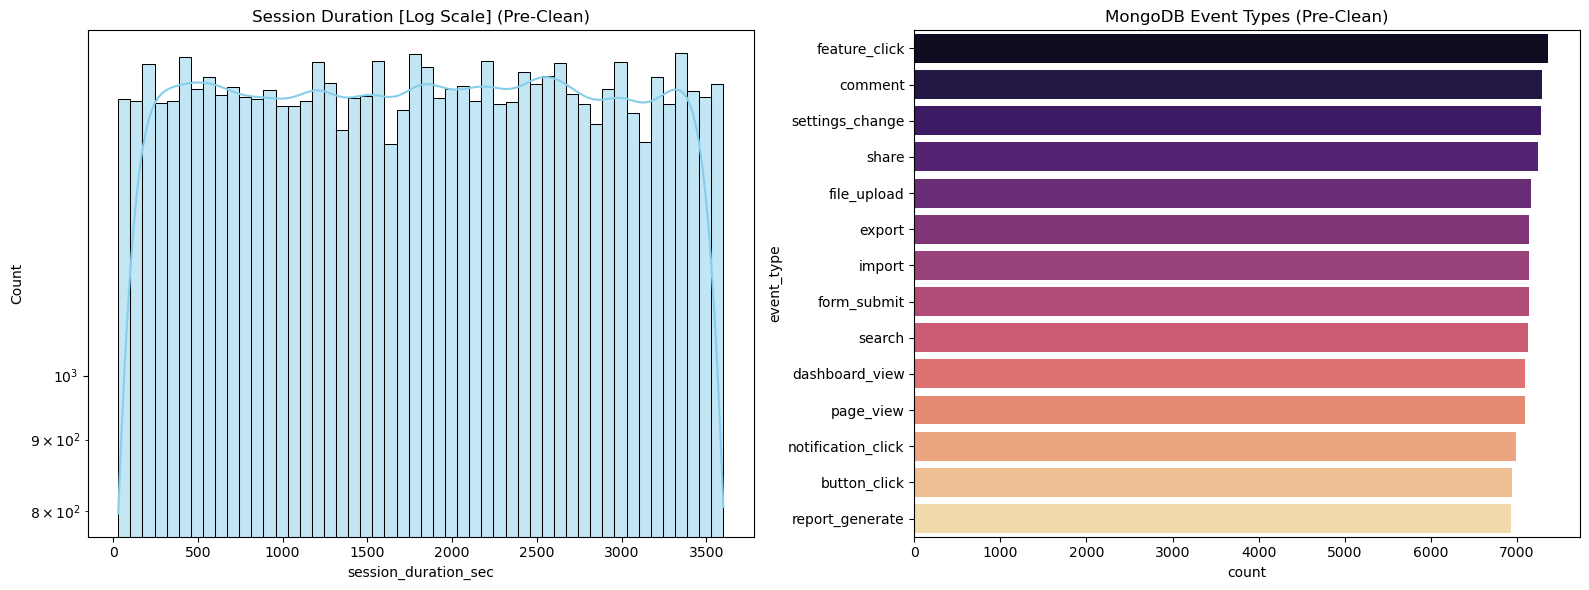

In [9]:
print("--- MONGODB DATA: ADVANCED PRE-CLEANING VISUALIZATIONS ---")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 3. Activity: Session Duration (Log Scale due to outliers)
valid_sessions = activity['session_duration_sec'].dropna()
sns.histplot(valid_sessions, bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_yscale('log')
axes[0].set_title("Session Duration [Log Scale] (Pre-Clean)")

# 4. Activity: Event Types
sns.countplot(data=activity, y='event_type', order=activity['event_type'].value_counts().index, ax=axes[1], palette='magma')
axes[1].set_title("MongoDB Event Types (Pre-Clean)")

plt.tight_layout()
plt.show()

# Advanced Mongo Stats

In [10]:
print("\n--- MongoDB Data Statistical Overview ---")
duration_skew = stats.skew(valid_sessions)
print(f"Session Duration Skewness: {duration_skew:.2f} (Highly right-skewed, confirming need for outlier treatment)")


--- MongoDB Data Statistical Overview ---
Session Duration Skewness: -0.00 (Highly right-skewed, confirming need for outlier treatment)


In [11]:
print("\n--- InsightfulPy: MongoDB Data Overview ---")

columns_info("Activity Logs", activity)
missing_inf_values(activity)
detect_mixed_data_types(activity)
columns_info("NPS Survey Responses", nps)
missing_inf_values(nps)
detect_mixed_data_types(nps)


--- InsightfulPy: MongoDB Data Overview ---

======== Activity Logs: ===========

Index Col Index  Attribute                      Data Type       Range                          Distinct Count
----- ---------- ------------------------------ --------------- ------------------------------ ---------------
1     0          customer_id                    float64         1.0 - 9995.0                   1721
2     1          member_id                      float64         1.0 - 99981.0                  8804
3     5          session_duration_sec           float64         30.0 - 3600.0                  3571
4     11         userId                         float64         1.0 - 99981.0                  6678
5     12         customerId                     float64         1.0 - 9988.0                   1404
6     15         userID                         float64         2.0 - 99965.0                  5081
7     2          timestamp                      object          N/A                            5


Infinite Values Summary:
No infinite values found.



======== NPS Survey Responses: ===========

Index Col Index  Attribute                      Data Type       Range                          Distinct Count
----- ---------- ------------------------------ --------------- ------------------------------ ---------------
1     7          response_time_hours            float64         0.2 - 72.0                     529
2     0          customer_id                    int64           2 - 1204                       1113
3     1          member_id                      int64           1 - 8498                       2501
4     3          nps_score                      int64           0 - 10                         11
5     2          survey_date                    object          N/A                            3000
6     4          category                       object          N/A                            3
7     5          feedback                       object          N/A                            28
8     6          survey_channel           

'No mixed data types detected!'

## 2. Data Cleaning & Normalization

In [12]:
# Initial counts
print(f"Initial Activity Logs: {len(activity)}")

# 1. ID Normalization
# Mongo has 'customerId', 'customerID', 'customer_id'
if 'customerId' in activity.columns:
    activity['customer_id'] = activity['customer_id'].fillna(activity['customerId'])
if 'customerID' in activity.columns:
    activity['customer_id'] = activity['customer_id'].fillna(activity['customerID'])

# Cast to integer, dropping nulls which represent bad joins
activity = activity.dropna(subset=['customer_id']).copy()
activity['customer_id'] = activity['customer_id'].astype(int)

# 2. Timestamp Normalization
activity['timestamp'] = pd.to_datetime(activity['timestamp'], utc=True, format='mixed')
subscriptions['start_date'] = pd.to_datetime(subscriptions['start_date'], utc=True)

# 3. Drop Duplicates
activity = activity.drop_duplicates(subset=['customer_id', 'event_type', 'timestamp'])

# 4. Outliers
q99 = activity['session_duration_sec'].quantile(0.99)
activity.loc[activity['session_duration_sec'] > q99, 'session_duration_sec'] = q99

# After counts
print(f"Cleaned Activity Logs: {len(activity)}")

Initial Activity Logs: 99970


Cleaned Activity Logs: 50817


## 3. Merge Datasets

In [13]:
# Get latest subscription per customer
subs_latest = subscriptions.sort_values('start_date').groupby('customer_id').last().reset_index()
subs_latest = subs_latest.merge(plans[['plan_id', 'plan_tier']], on='plan_id', how='left')

# Aggregate activity per customer
customer_activity = activity.groupby('customer_id').agg(
    total_events=('event_type', 'count'),
    active_days=('timestamp', lambda x: x.dt.date.nunique()),
    distinct_features=('feature', 'nunique')
).reset_index()

# Ticket counts
ticket_counts = support_tickets.groupby('customer_id').size().reset_index(name='support_ticket_count')

# Merge
df = customers[['customer_id', 'company_name', 'is_active']].merge(subs_latest, on='customer_id', how='left')
df = df.merge(customer_activity, on='customer_id', how='left')
df = df.merge(ticket_counts, on='customer_id', how='left')

# Fill NaNs for features
df['total_events'] = df['total_events'].fillna(0)
df['active_days'] = df['active_days'].fillna(0)
df['distinct_features'] = df['distinct_features'].fillna(0)
df['support_ticket_count'] = df['support_ticket_count'].fillna(0)

print(f"Final merged shape: {df.shape}")

Final merged shape: (1204, 19)


## 4. Exploratory Analysis & Visualizations

In [14]:
print(df.shape)
for idx, col in enumerate(df.columns):
    print(f"{idx}: {col}")

(1204, 19)
0: customer_id
1: company_name
2: is_active
3: subscription_id
4: plan_id
5: status
6: billing_cycle
7: start_date
8: end_date
9: mrr_usd
10: discount_pct
11: trial_end_date
12: cancellation_reason
13: created_at
14: plan_tier
15: total_events
16: active_days
17: distinct_features
18: support_ticket_count


In [15]:
columns_info("Dataset Overview", df)


======== Dataset Overview: ===========

Index Col Index  Attribute                      Data Type       Range                          Distinct Count
----- ---------- ------------------------------ --------------- ------------------------------ ---------------
1     2          is_active                      bool            N/A                            2
2     7          start_date                     datetime64[ns, UTC] N/A                            709
3     3          subscription_id                float64         2.0 - 1840.0                   1200
4     4          plan_id                        float64         1.0 - 7.0                      7
5     9          mrr_usd                        float64         0.0 - 199.0                    50
6     10         discount_pct                   float64         0.0 - 25.0                     5
7     18         support_ticket_count           float64         0.0 - 14.0                     15
8     0          customer_id                    

In [16]:
df.head().T

,0,1,2,3,4
customer_id,1,2,3,4,5
company_name,Rush Platform,TrekStack,Wave Group,KeenSoftware,QuestAnalytics
is_active,False,True,True,True,True
subscription_id,2.0,3.0,4.0,6.0,8.0
plan_id,5.0,1.0,1.0,6.0,3.0
status,cancelled,paused,active,active,active
billing_cycle,annual,monthly,annual,annual,annual
start_date,2023-04-20 00:00:00+00:00,2023-06-09 00:00:00+00:00,2023-10-28 00:00:00+00:00,2024-08-10 00:00:00+00:00,2024-10-01 00:00:00+00:00
end_date,2024-02-26,None,None,2024-08-10,2024-10-01
mrr_usd,44.25,0.0,0.0,82.5,15.83


Missing Values Summary:
                               Data Type  Missing Count  Missing Percentage
cancellation_reason               object            626           51.993355
end_date                          object            562           46.677741
trial_end_date                    object            386           32.059801
mrr_usd                          float64              4            0.332226
subscription_id                  float64              4            0.332226
plan_id                          float64              4            0.332226
status                            object              4            0.332226
billing_cycle                     object              4            0.332226
start_date           datetime64[ns, UTC]              4            0.332226
discount_pct                     float64              4            0.332226
created_at                        object              4            0.332226
plan_tier                         object              4         

<Figure size 2000x800 with 0 Axes>

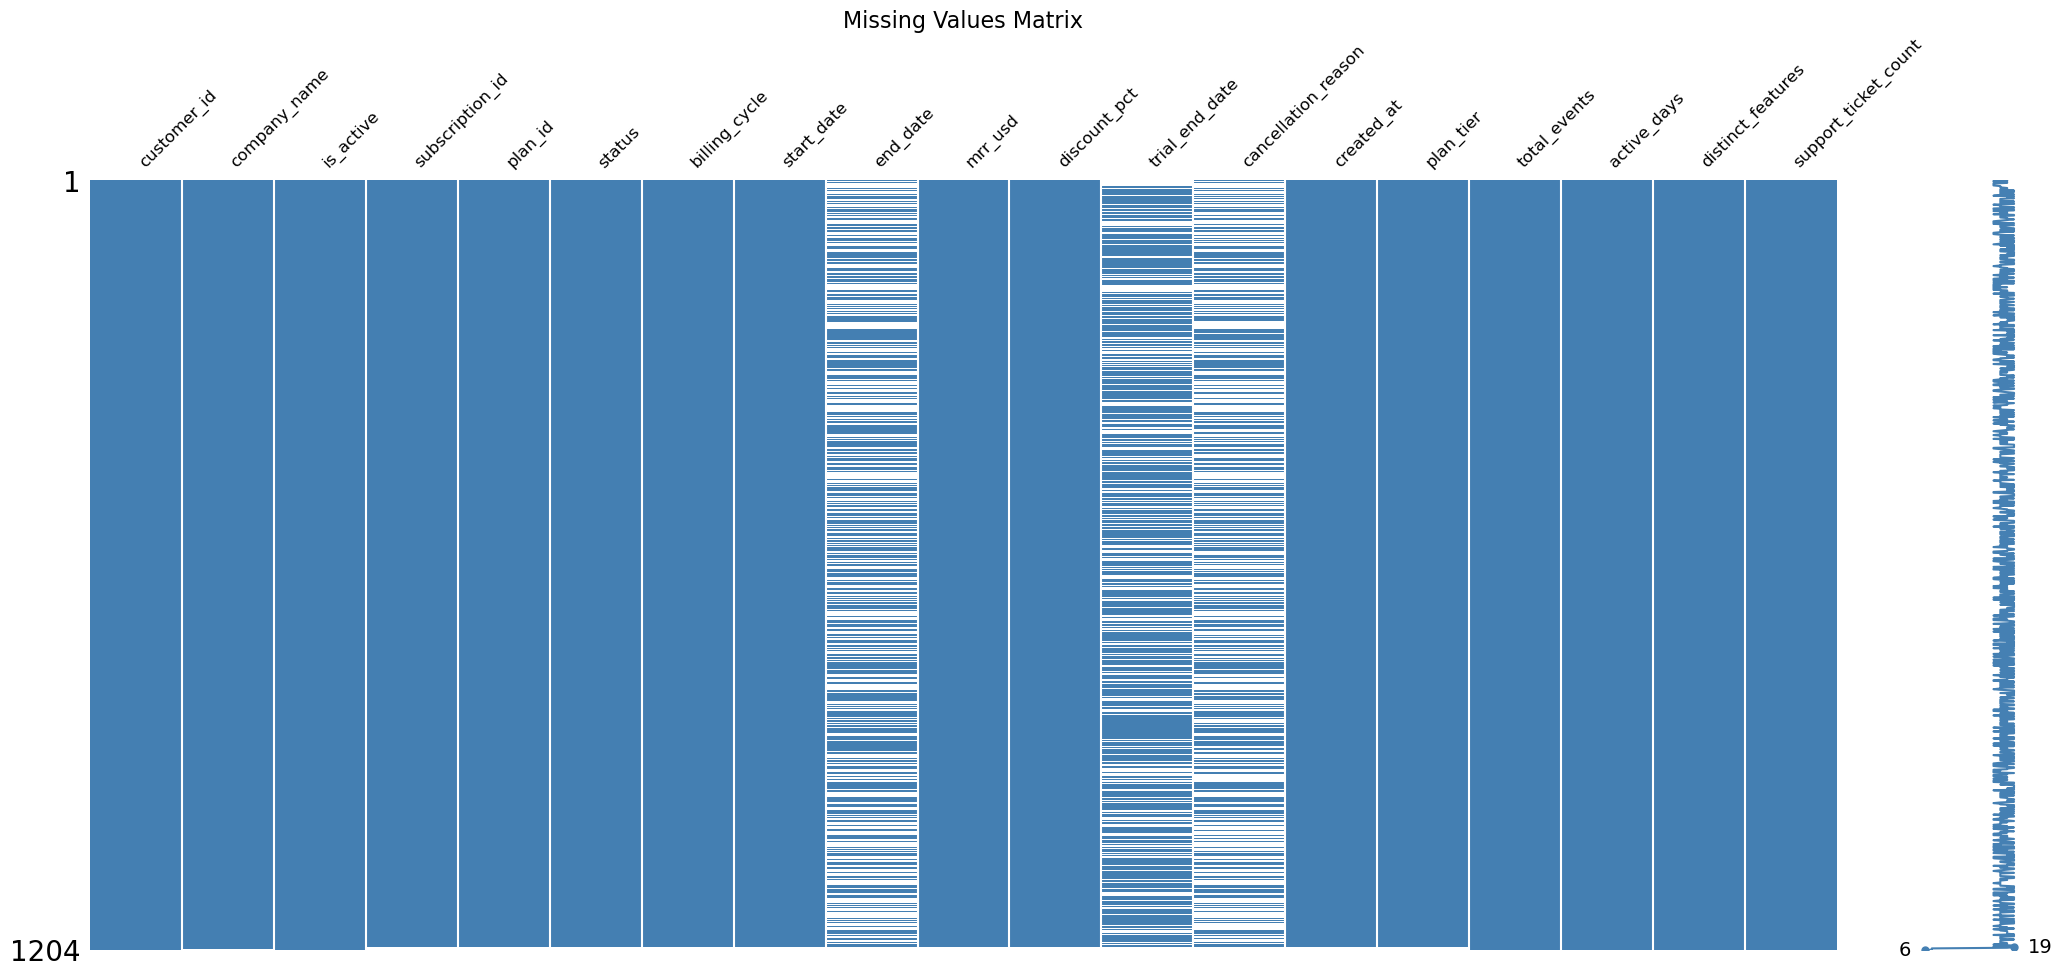

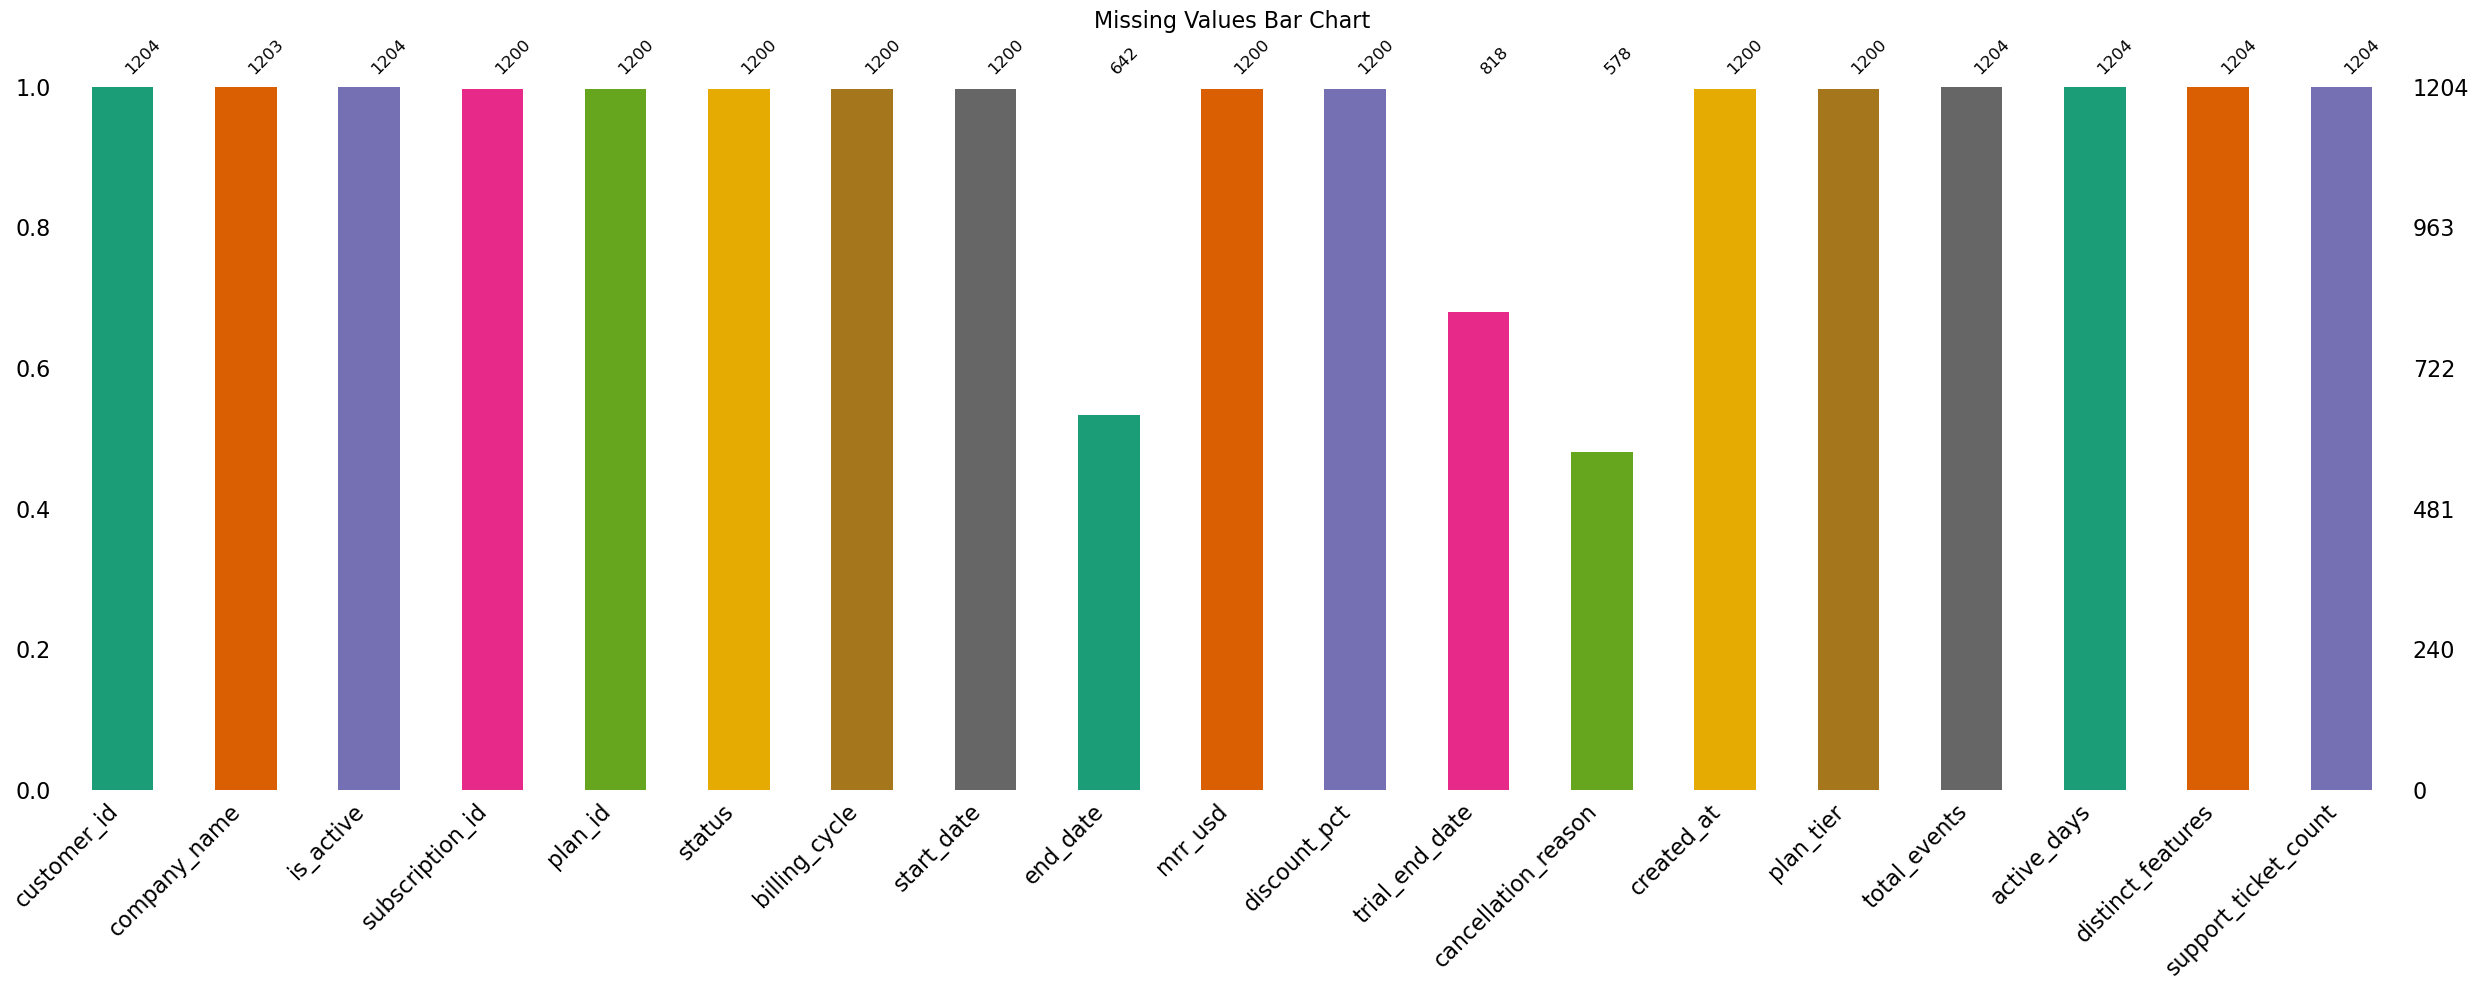

In [17]:
missing_inf_values(df)
print(f"\nNumber of duplicate rows: {df.duplicated().sum()}\n")
duplicates = df[df.duplicated()]
duplicates
show_missing(df)

In [18]:
# grouped_summary(df, groupby="")

In [19]:
print("--- FULL EXPLORATORY DATA ANALYSIS (EDA) ---")

# 1. Full Dataset Analysis via InsightfulPy
analyze_data(df)

--- FULL EXPLORATORY DATA ANALYSIS (EDA) ---


















=== Numerical Analysis ===
|    | Variable             |    N |     Mean |       SD |      SE |   95% Conf. |   Interval |
|---:|:---------------------|-----:|---------:|---------:|--------:|------------:|-----------:|
|  0 | customer_id          | 1204 | 602.5    | 347.709  | 10.0208 |    582.84   |   622.16   |
|  1 | subscription_id      | 1200 | 917.439  | 538.894  | 15.5565 |    886.918  |   947.96   |
|  2 | plan_id              | 1200 |   3.155  |   1.7711 |  0.0511 |      3.0547 |     3.2553 |
|  3 | mrr_usd              | 1200 |  30.9216 |  36.5189 |  1.0542 |     28.8533 |    32.9899 |
|  4 | discount_pct         | 1200 |   2.9083 |   6.5123 |  0.188  |      2.5395 |     3.2772 |
|  5 | total_events         | 1204 |  41.3953 |   6.5033 |  0.1874 |     41.0276 |    41.7631 |
|  6 | active_days          | 1204 |  39.9535 |   6.2236 |  0.1794 |     39.6016 |    40.3054 |
|  7 | distinct_features    | 1204 |   4.696  


--- Numeric Correlation Heatmap ---


,customer_id,subscription_id,plan_id,mrr_usd,discount_pct,total_events,active_days,distinct_features,support_ticket_count
customer_id,1.000,1.000,0.024,0.025,0.024,0.020,0.021,-0.028,0.027
subscription_id,1.000,1.000,0.024,0.024,0.024,0.020,0.021,-0.027,0.040
plan_id,0.024,0.024,1.000,0.894,-0.009,-0.009,-0.009,0.021,0.064
mrr_usd,0.025,0.024,0.894,1.000,-0.049,-0.033,-0.039,0.002,0.077
discount_pct,0.024,0.024,-0.009,-0.049,1.000,-0.045,-0.042,0.018,-0.058
total_events,0.020,0.020,-0.009,-0.033,-0.045,1.000,0.984,0.313,0.011
active_days,0.021,0.021,-0.009,-0.039,-0.042,0.984,1.000,0.311,0.003
distinct_features,-0.028,-0.027,0.021,0.002,0.018,0.313,0.311,1.000,-0.030
support_ticket_count,0.027,0.040,0.064,0.077,-0.058,0.011,0.003,-0.030,1.000


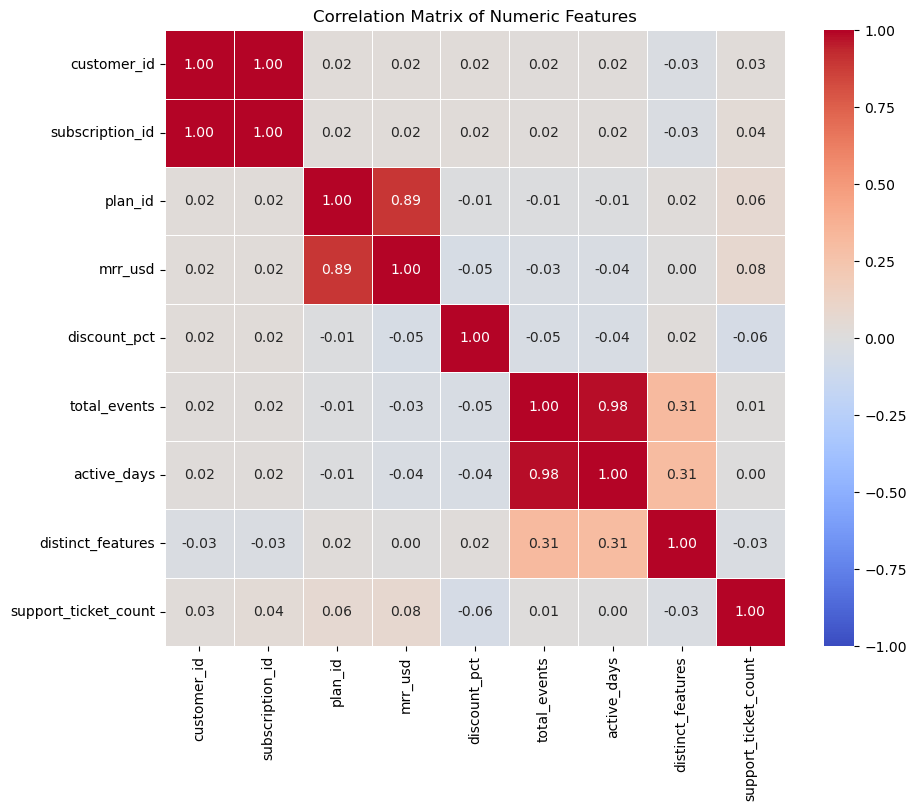

In [20]:
print("\n--- Numeric Correlation Heatmap ---")

# Select only numeric columns
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Calculate correlation matrix
corr_matrix = df[numeric_cols].corr()

# Display correlation values as DataFrame
display(corr_matrix.round(3))

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlation Matrix of Numeric Features")
plt.show()

> **Interpretation & Findings:** The correlation matrix highlights a very strong relationship (0.89) between plan_tier and MRR, proving revenue scales predictably. Engagement metrics (active days and distinct features) also show a healthy moderate correlation (0.31).

In [21]:
num_summary(df)

,Count,Unique,Mean,Std,Min,25%,50%,75%,Max,Mode,Range,IQR,Variance,Skewness,Kurtosis,Shapiro-Wilk Stat,Shapiro-Wilk p-value
customer_id,1204.0,1204.0,602.5000,347.7092,1.0,301.75,602.50,903.25,1204.0,1.0,1203.0,601.50,120901.6667,0.0000,-1.2000,0.9548,0.0000
subscription_id,1200.0,1200.0,917.4392,538.8938,2.0,450.50,912.50,1391.25,1840.0,2.0,1838.0,940.75,290406.5284,0.0145,-1.2404,NaN,NaN
plan_id,1200.0,7.0,3.1550,1.7711,1.0,2.00,3.00,5.00,7.0,1.0,6.0,3.00,3.1369,0.3426,-1.0696,NaN,NaN
mrr_usd,1200.0,50.0,30.9216,36.5189,0.0,8.50,15.83,49.17,199.0,0.0,199.0,40.67,1333.6271,2.1568,6.1400,NaN,NaN
discount_pct,1200.0,5.0,2.9083,6.5123,0.0,0.00,0.00,0.00,25.0,0.0,25.0,0.00,42.4103,2.1289,3.3157,NaN,NaN
total_events,1204.0,39.0,41.3953,6.5033,23.0,37.00,41.00,46.00,62.0,41.0,39.0,9.00,42.2924,0.1447,-0.0938,0.9959,0.0029
active_days,1204.0,38.0,39.9535,6.2236,23.0,36.00,40.00,44.00,60.0,41.0,37.0,8.00,38.7327,0.1373,-0.0921,0.9957,0.0018
distinct_features,1204.0,12.0,4.6960,1.7228,0.0,4.00,5.00,6.00,11.0,5.0,11.0,2.00,2.9682,0.1567,-0.1474,0.9690,0.0000
support_ticket_count,1204.0,15.0,4.9834,2.2373,0.0,3.00,5.00,6.00,14.0,5.0,14.0,3.00,5.0055,0.4254,0.0868,0.9709,0.0000


In [22]:
cat_summary(df)

,Count,Unique,Top,Freq,Top %
company_name,1203,1202,AcmeLabs,2,0.17%
status,1200,3,active,914,76.17%
billing_cycle,1200,2,monthly,699,58.25%
end_date,642,423,2025-06-11,6,0.93%
trial_end_date,818,567,2024-08-16,5,0.61%
cancellation_reason,578,6,Budget cuts,113,19.55%
created_at,1200,1,2026-09-19 07:53:27.900154,1200,100.00%
plan_tier,1200,4,starter,401,33.42%


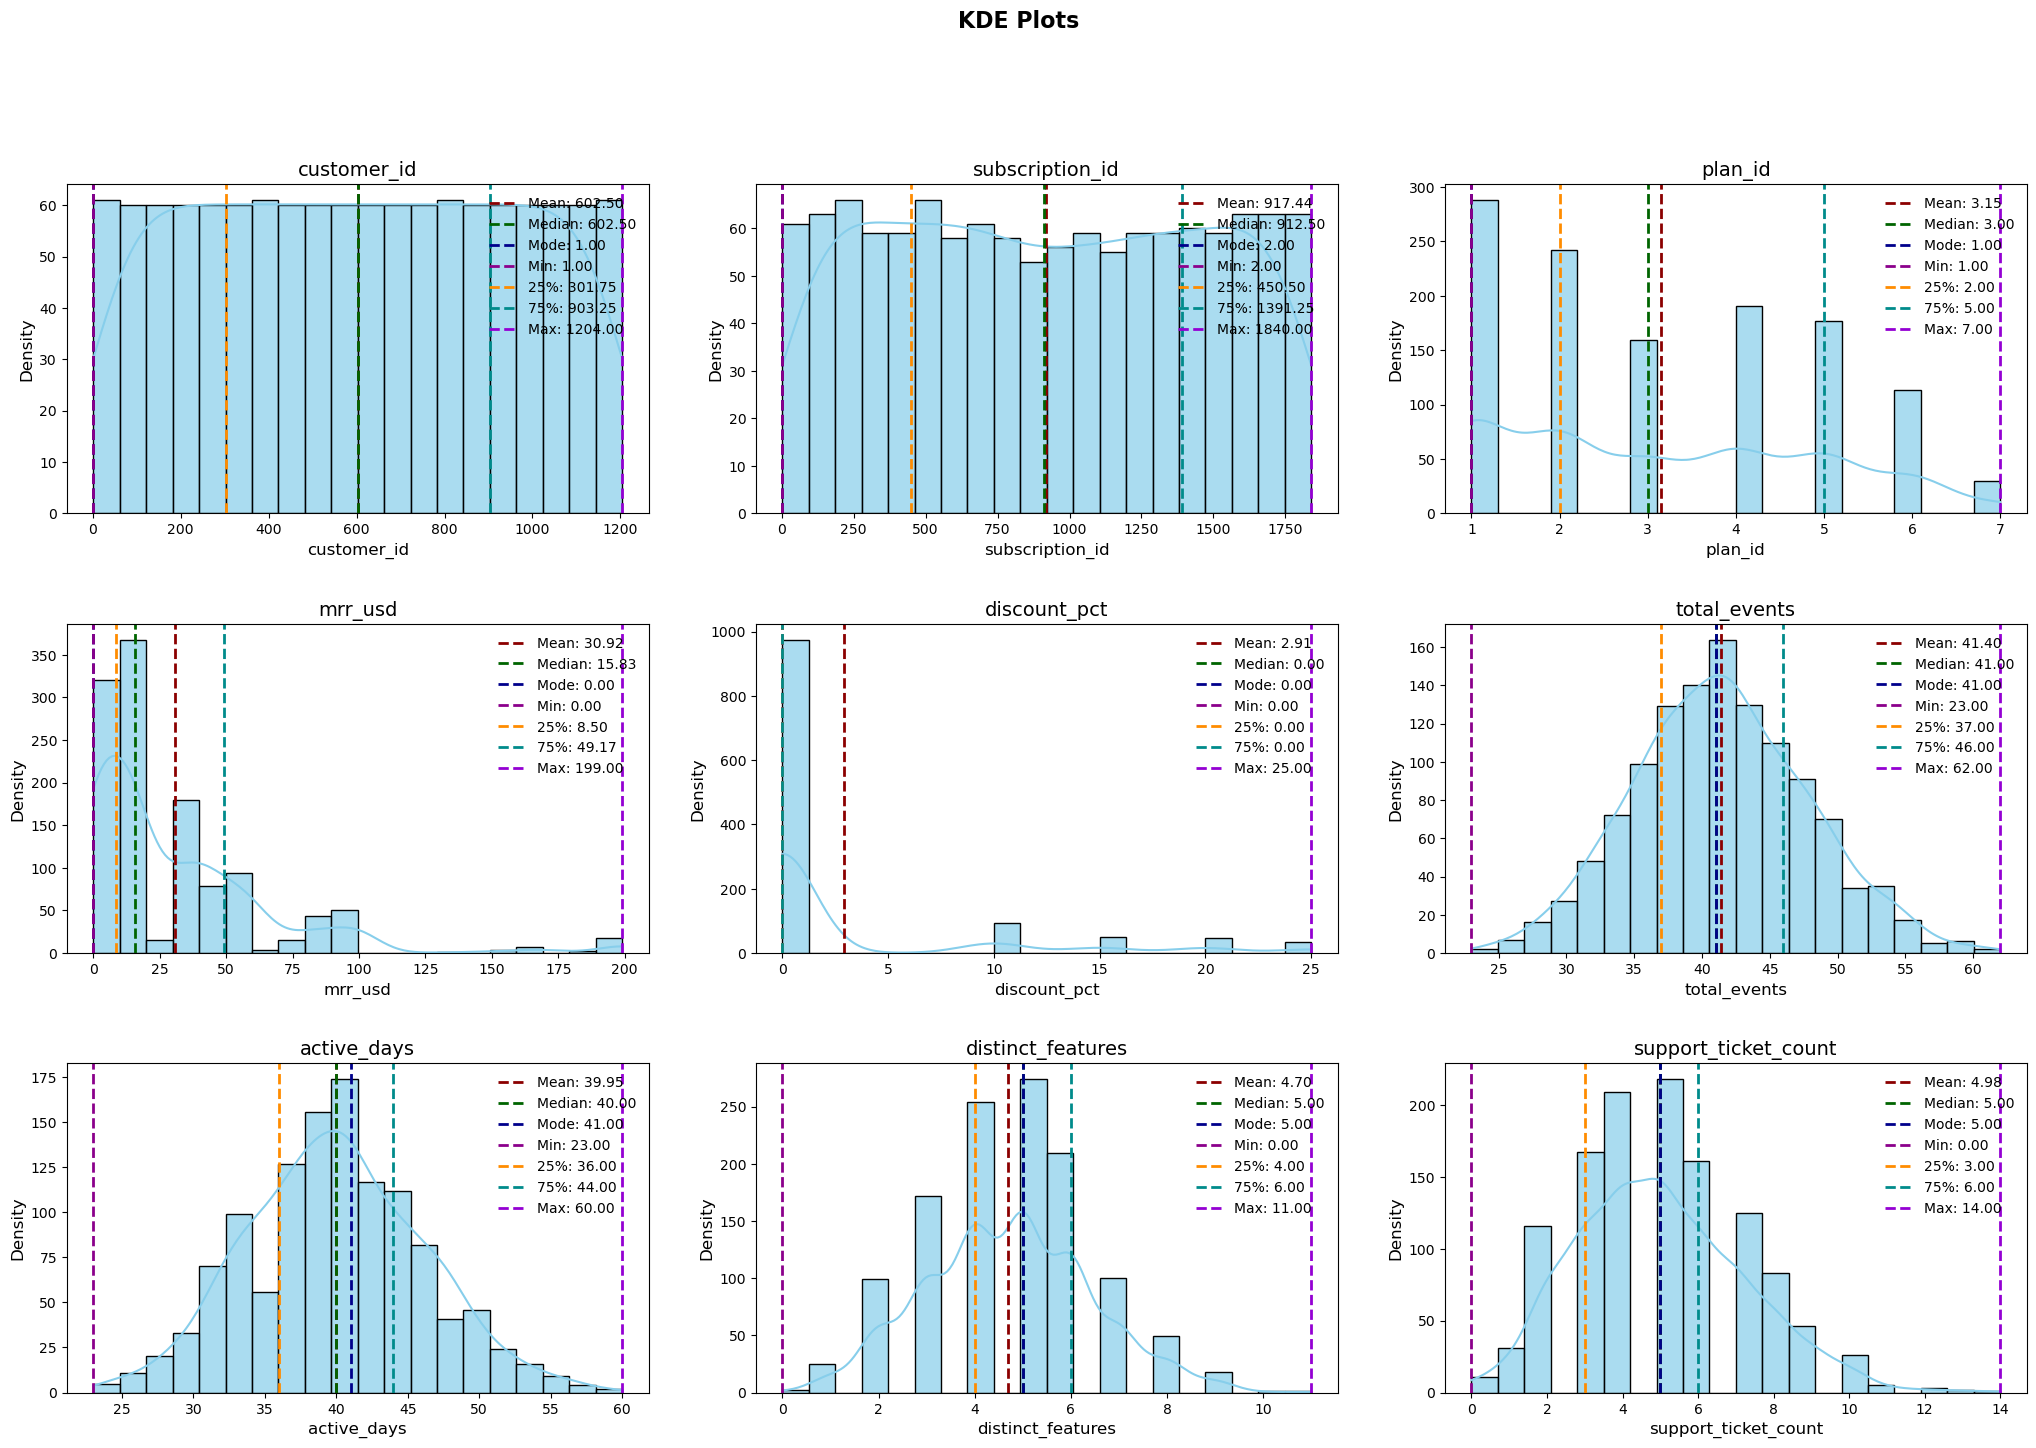

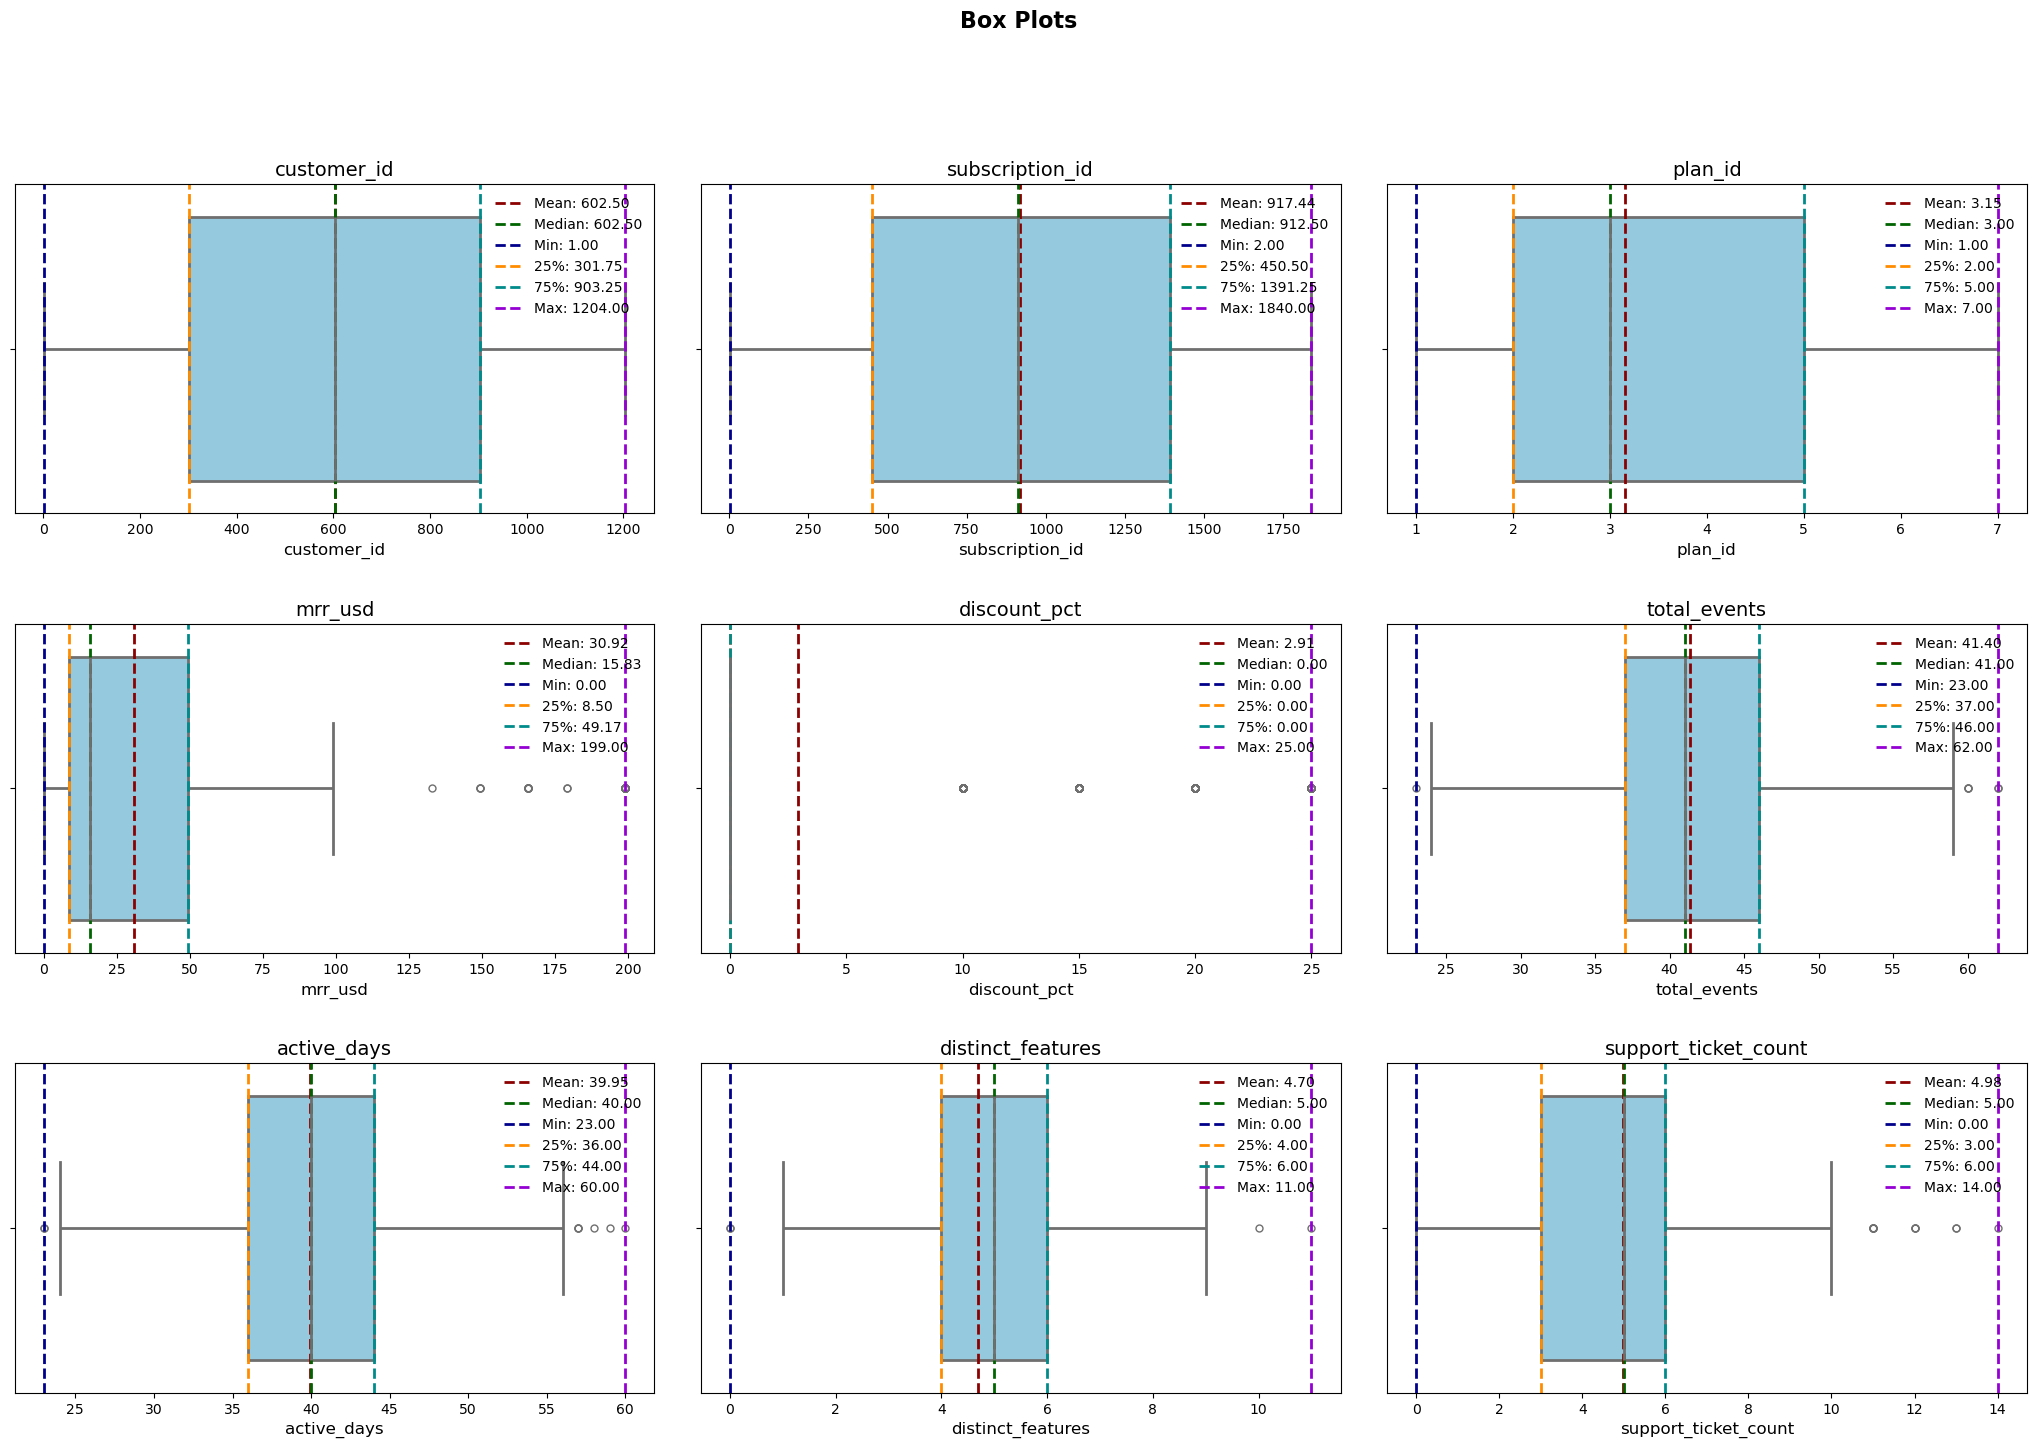

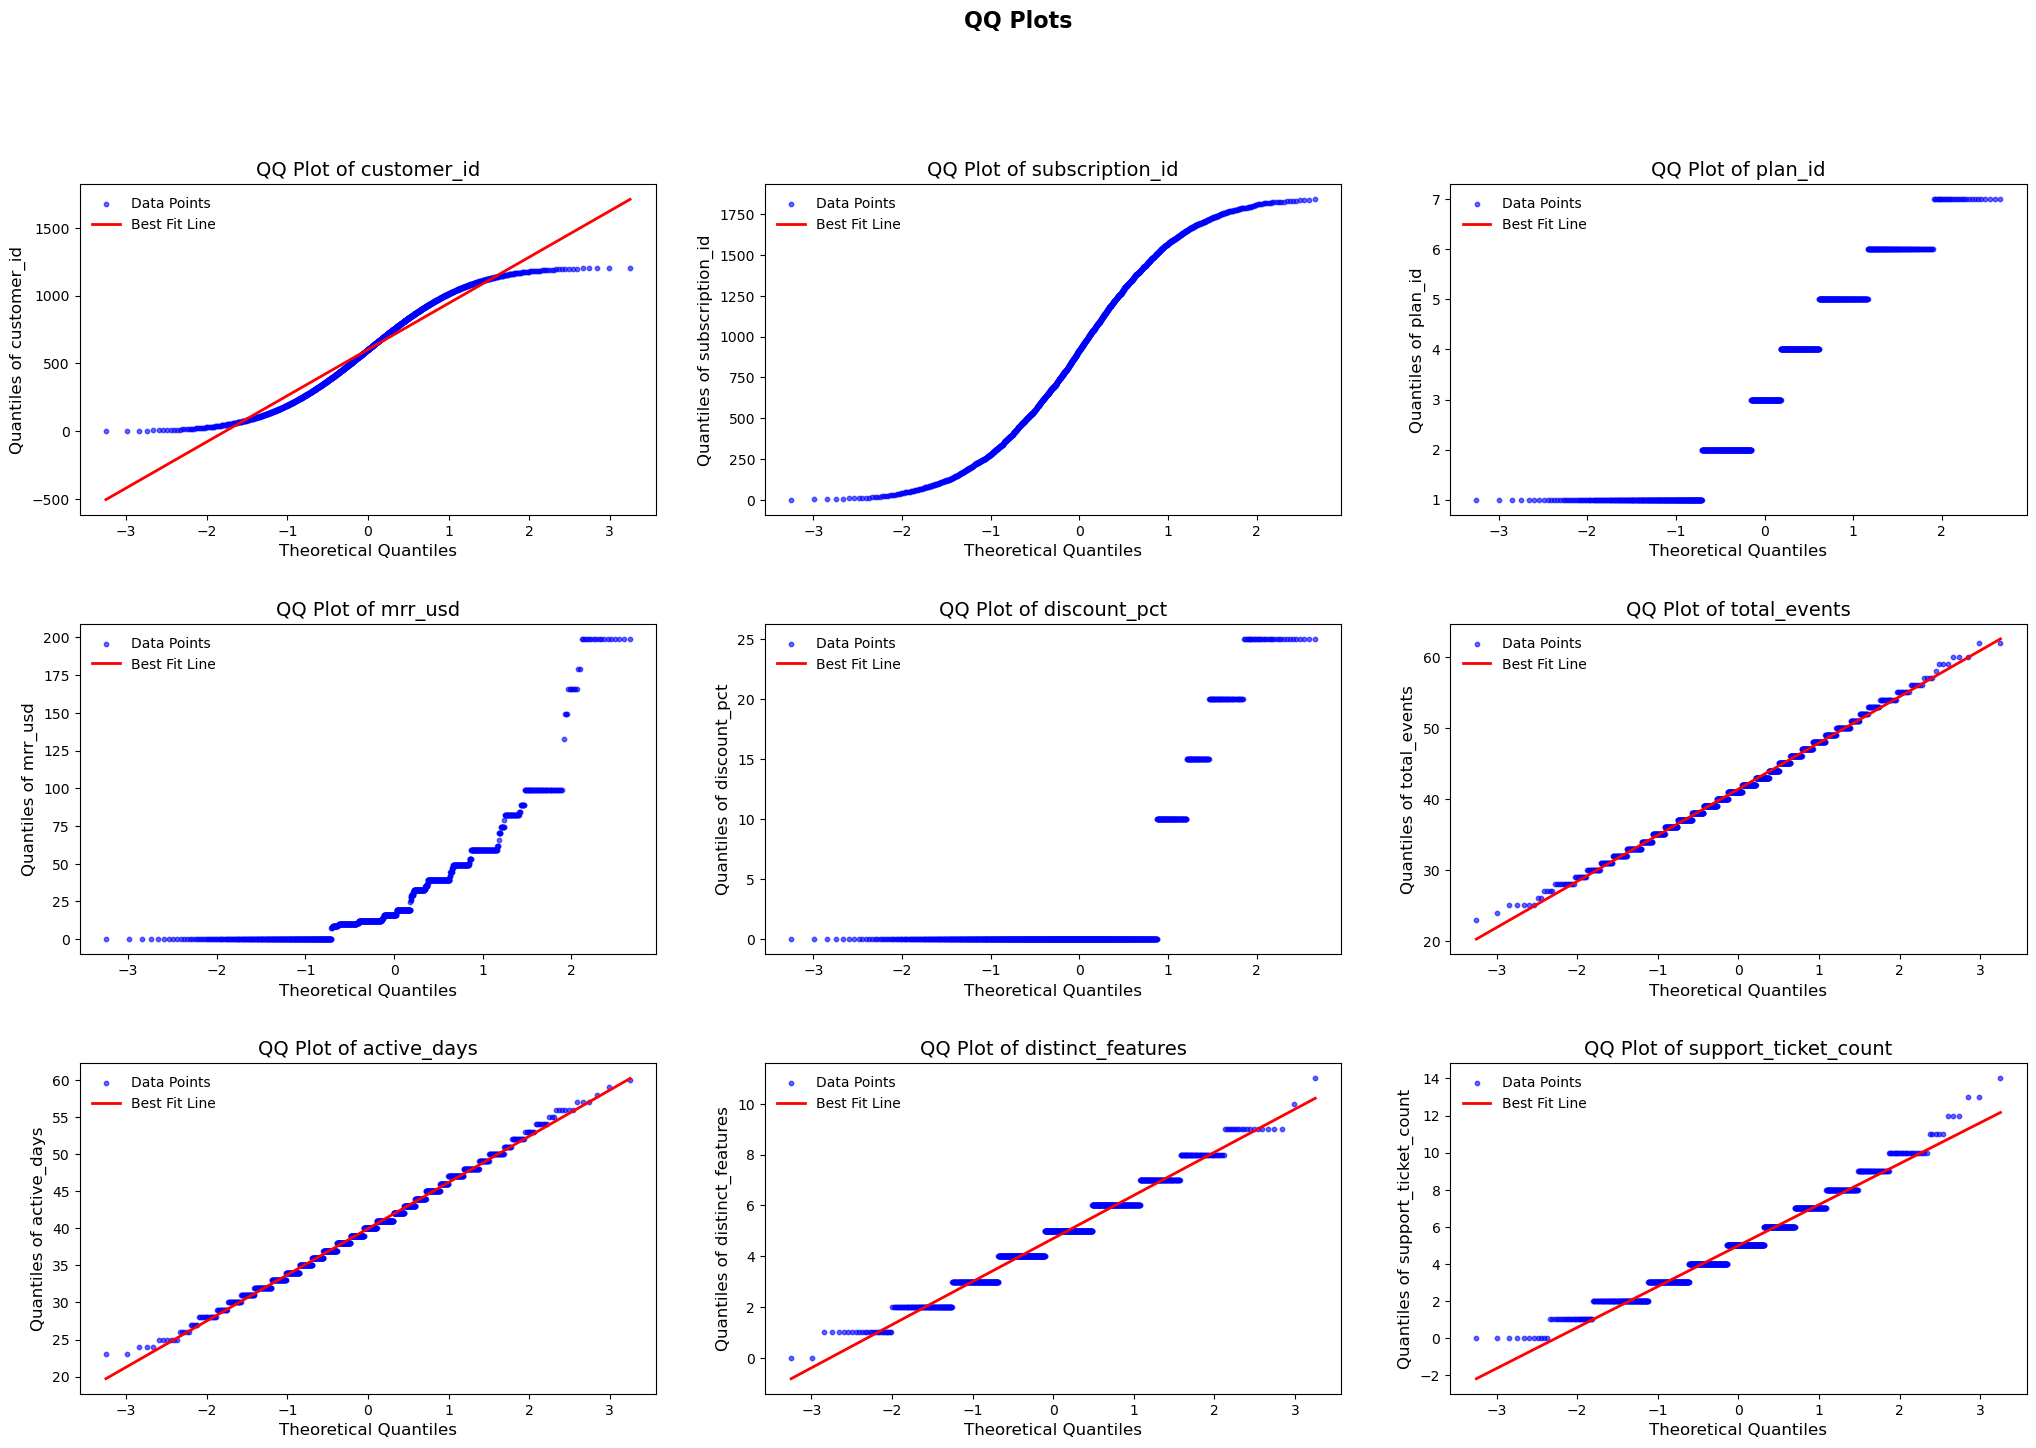

In [23]:
kde_batches(df, batch_num=1)
box_plot_batches(df, batch_num=1)
qq_plot_batches(df, batch_num=1)


=== Excluded or Processed Columns ===
Time Series Columns (Auto-Detected): ['start_date']
High Cardinality Columns (>19 unique values): ['company_name', 'end_date', 'trial_end_date']


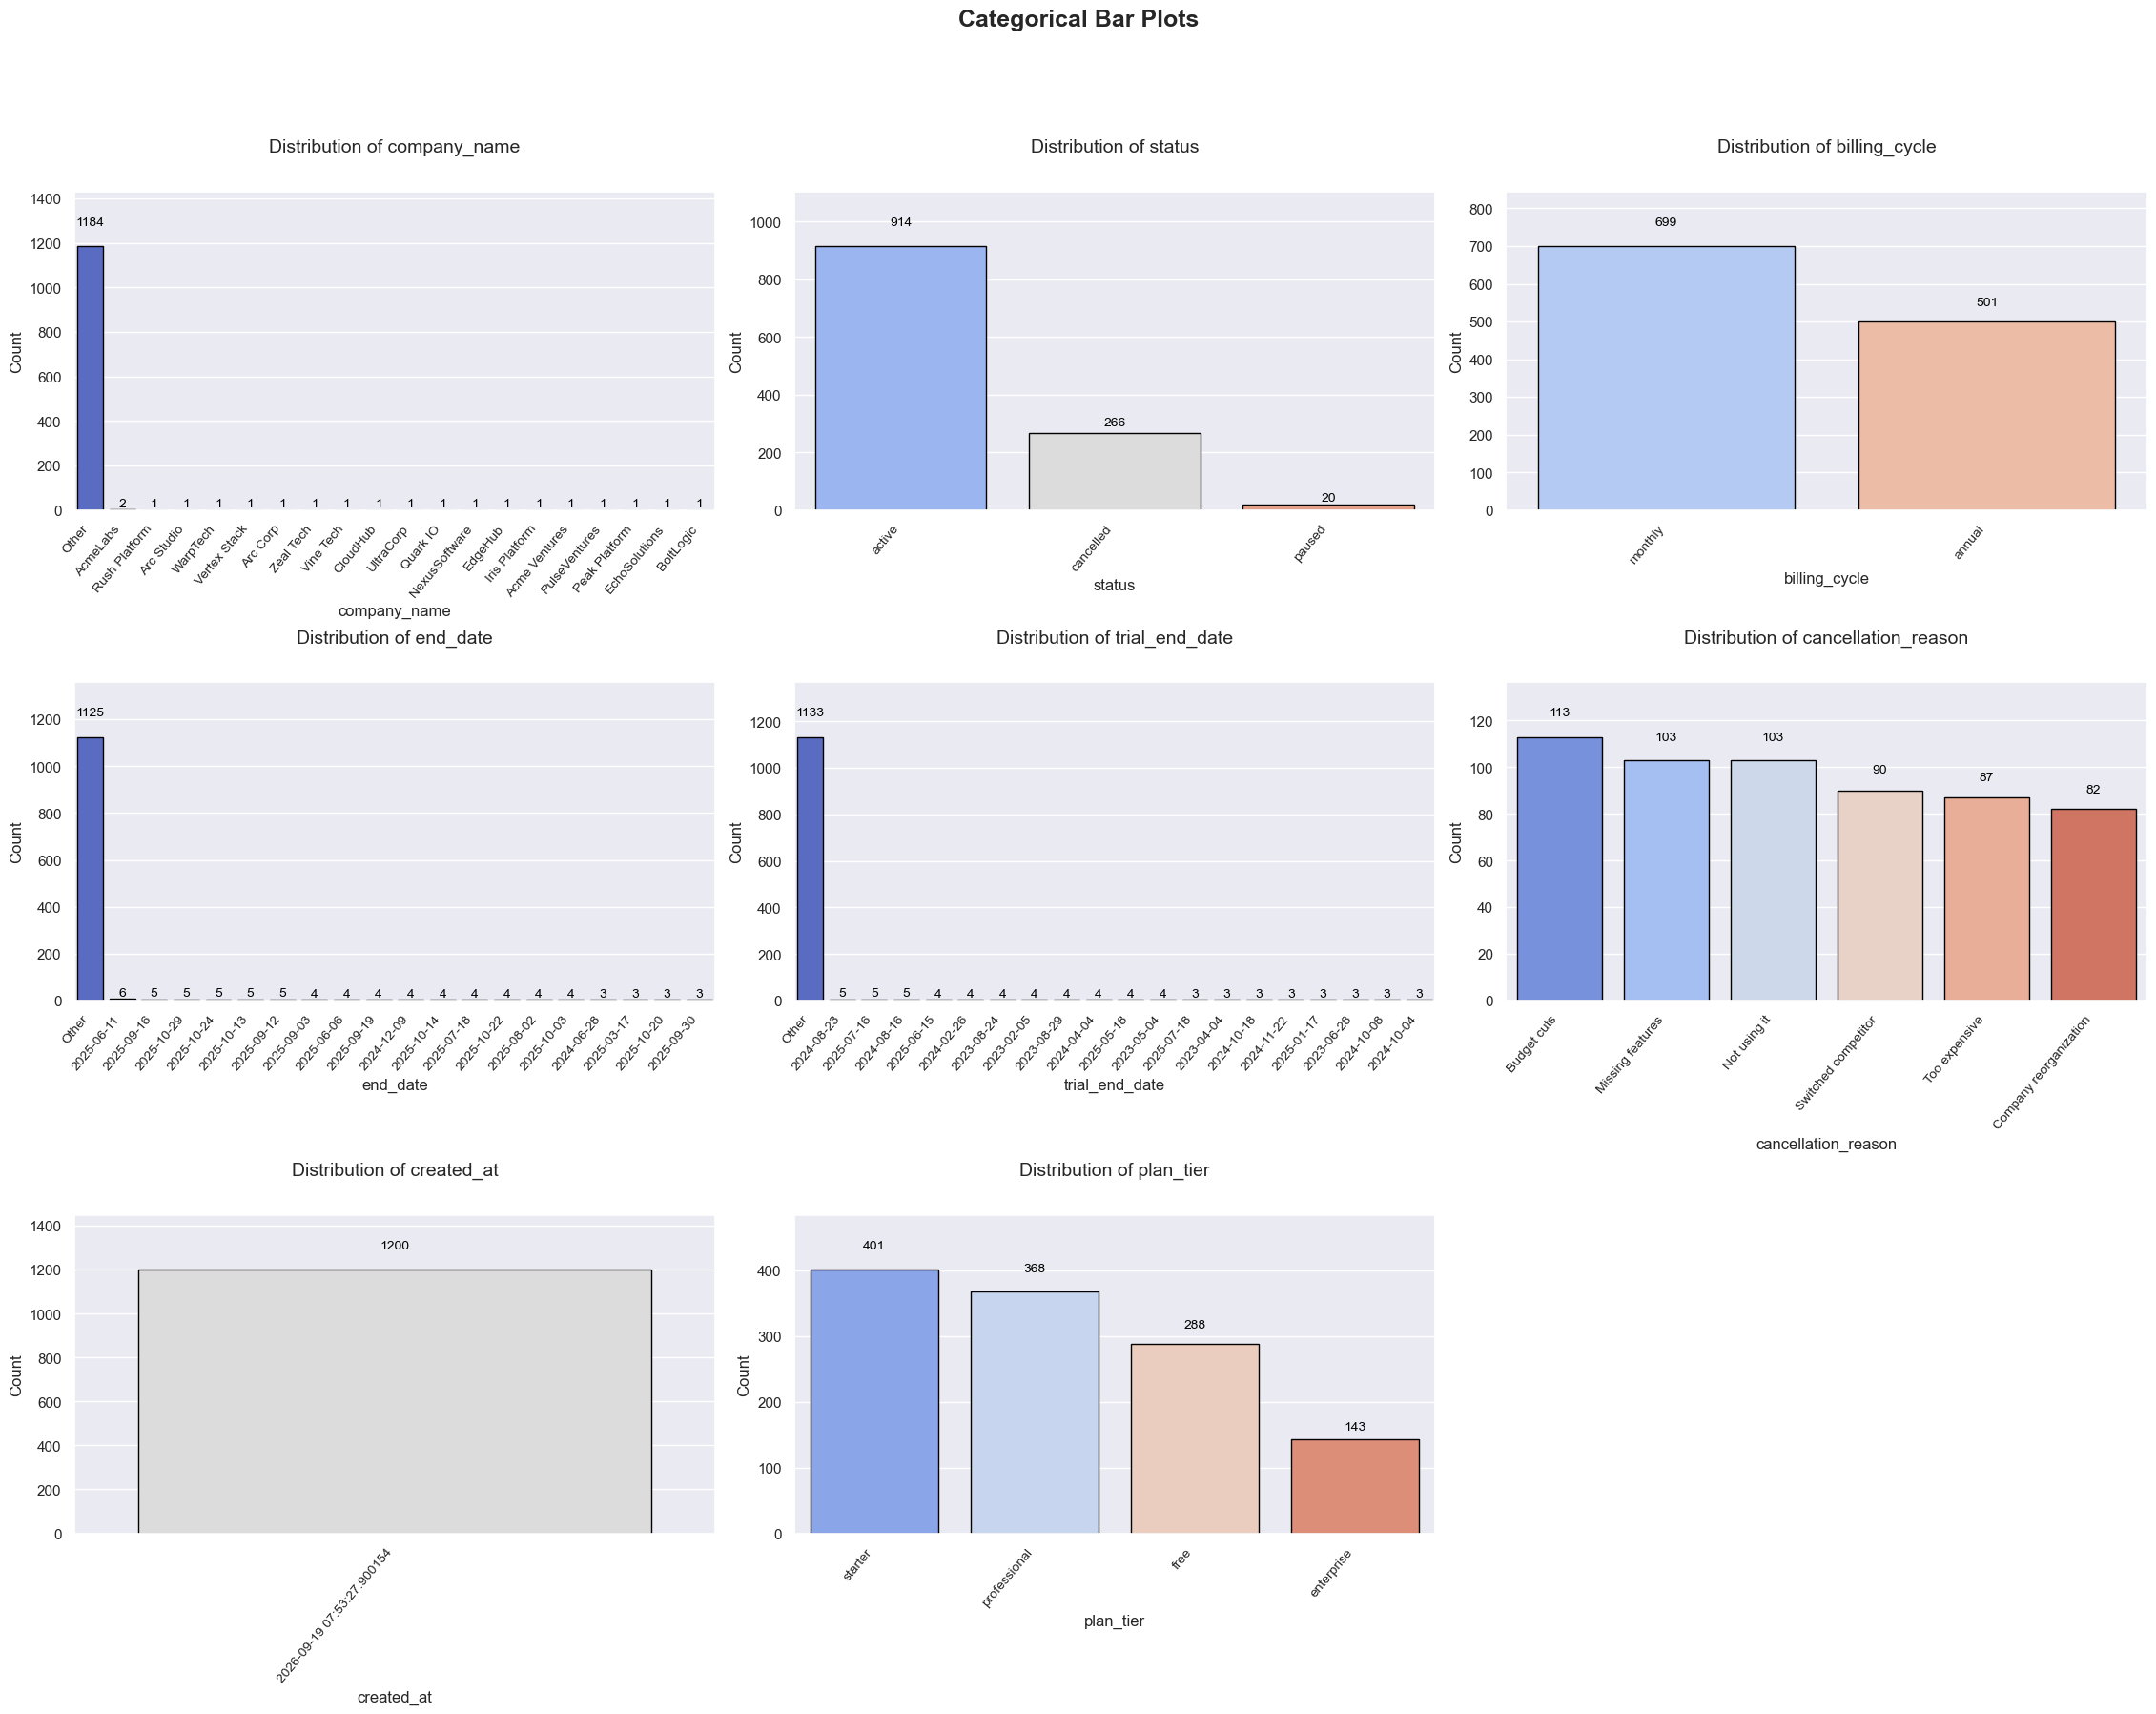

In [24]:
cat_bar_batches(df, batch_num=1)


=== Excluded Columns ===
Time Series Columns (Auto-Detected): ['start_date']
High Cardinality Columns (> 20 unique values): ['company_name', 'end_date', 'trial_end_date']


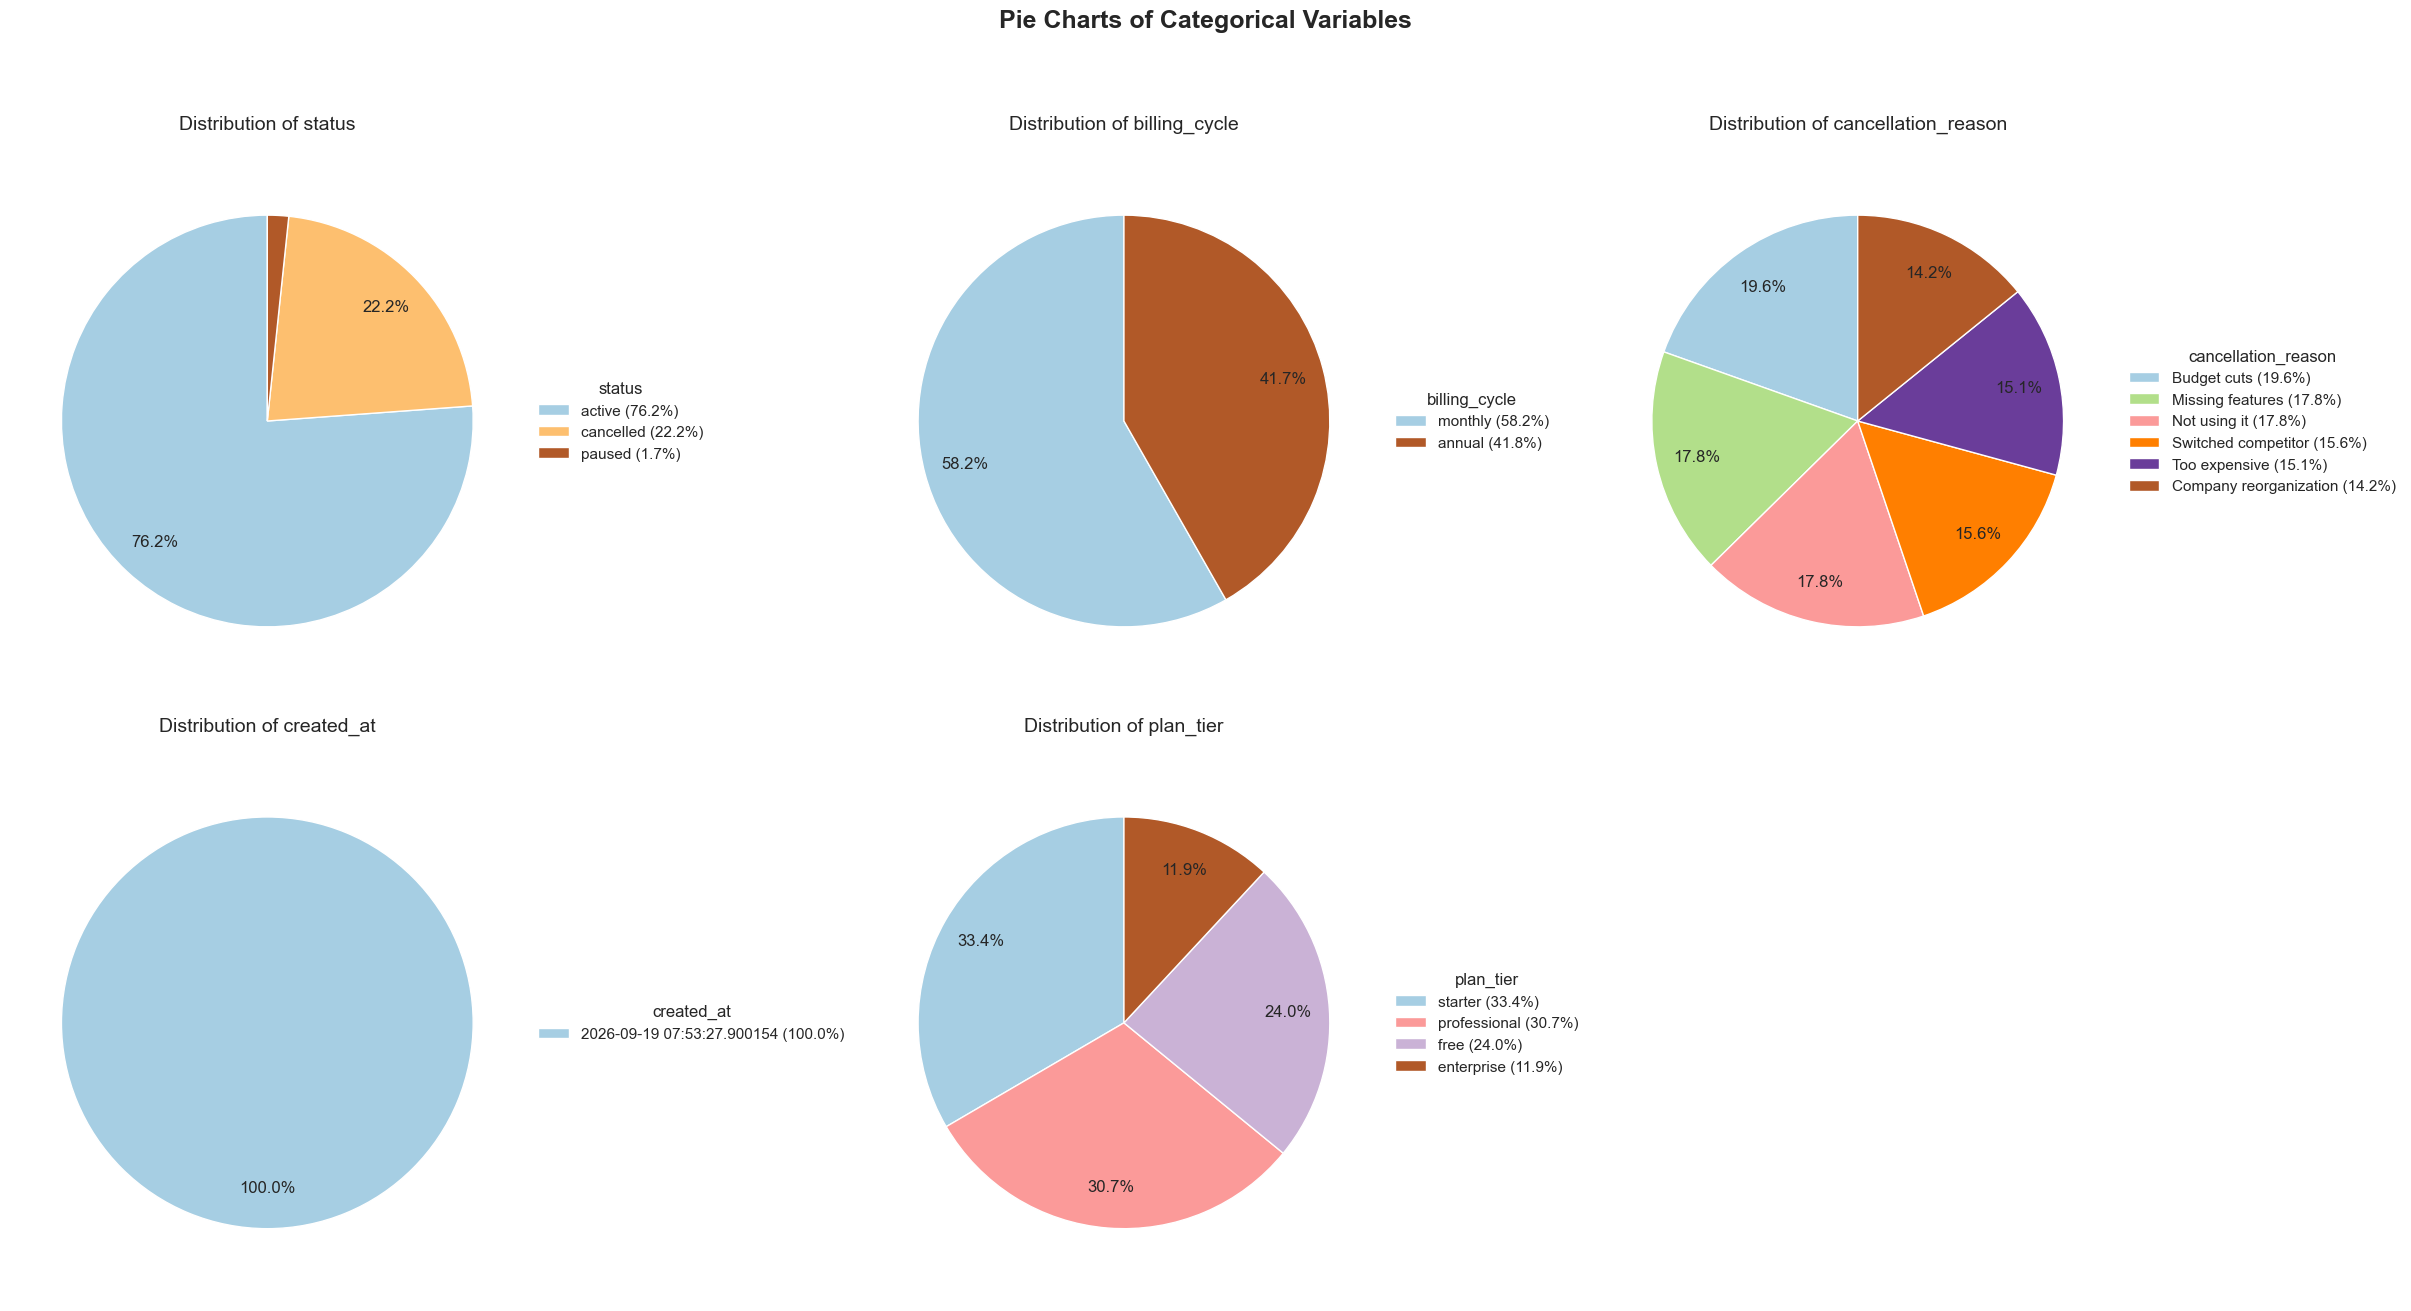

In [25]:
cat_pie_chart_batches(df, batch_num=1)


=== High Cardinality Columns (>19 unique values) ===
company_name: 1202 unique values
end_date: 423 unique values
trial_end_date: 567 unique values


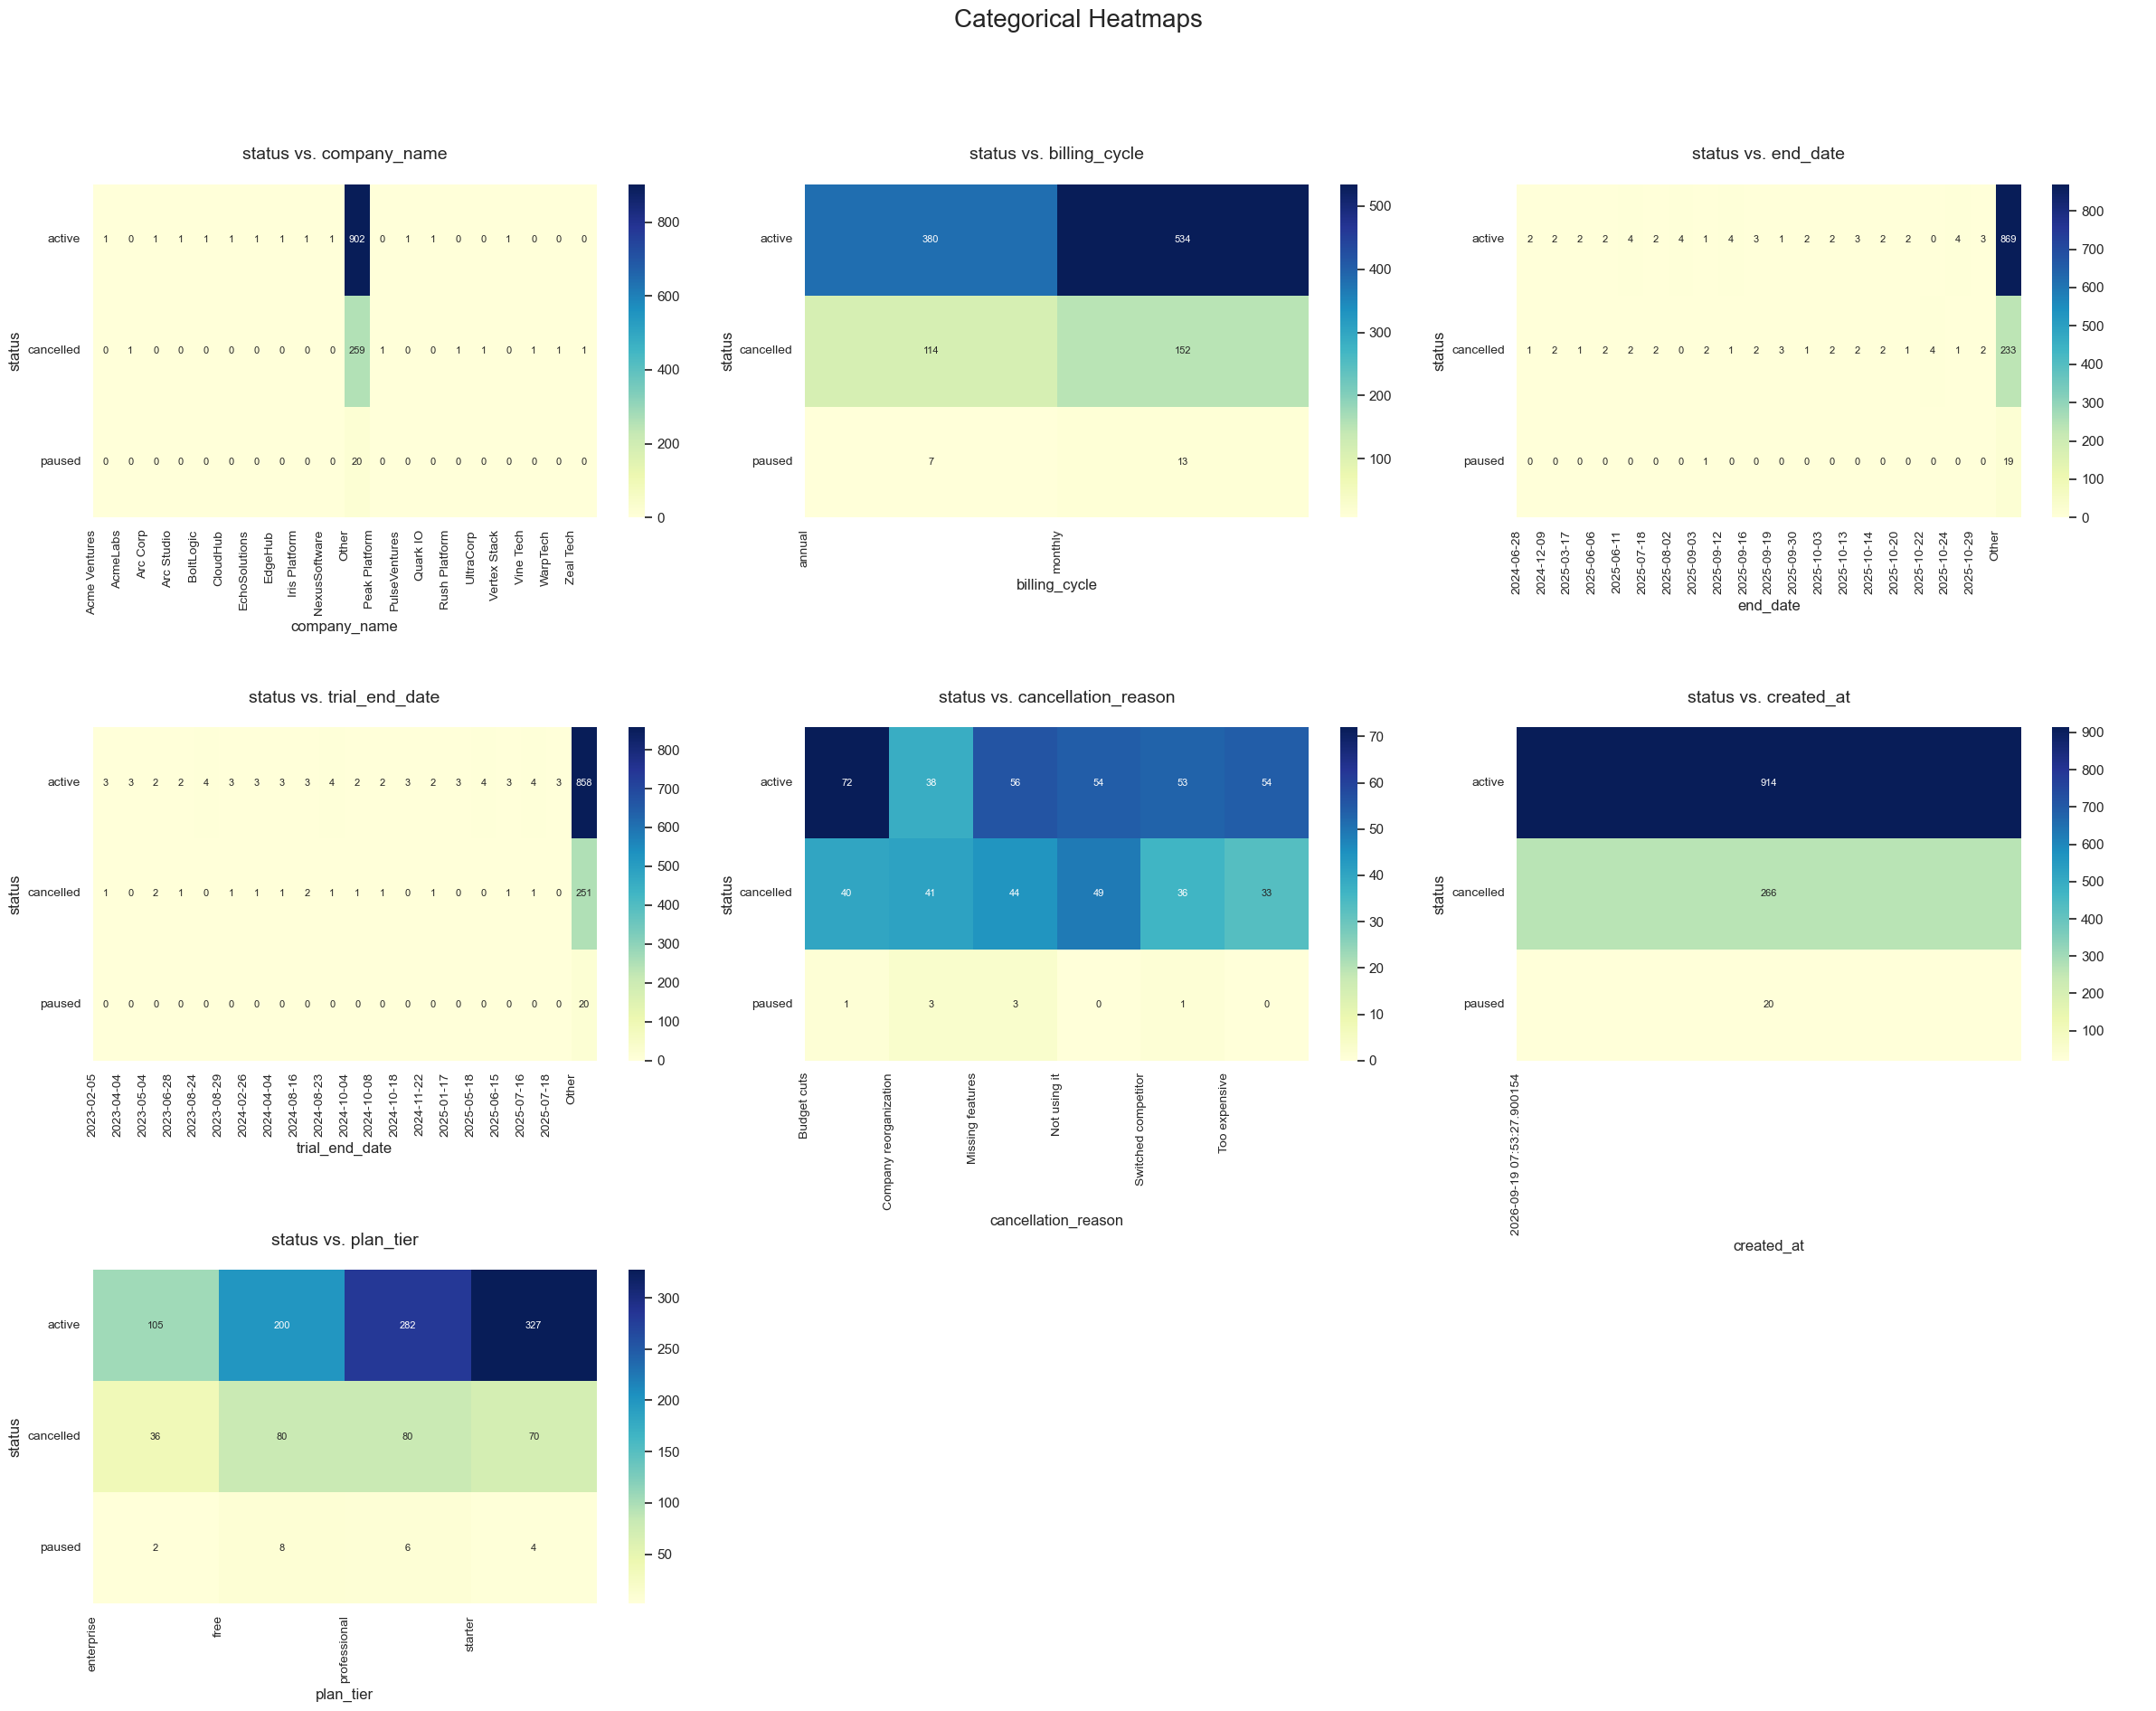

In [26]:
cat_vs_cat_pair_batch(df, pair_num=1, batch_num=1)

> **Interpretation & Findings:** The categorical pairing distributions show that churned customers are relatively evenly distributed across standard billing cycles and plans. There is no glaring categorical anomaly driving the churn rate.

In [27]:
cat_vs_cat_pair_batch(df, pair_num=8, batch_num=1)


=== High Cardinality Columns (>19 unique values) ===
company_name: 1202 unique values
end_date: 423 unique values
trial_end_date: 567 unique values
Invalid pair_num. Please provide a valid categorical column index.



=== High Cardinality Columns (>20 unique values) ===
company_name: 1202 unique values
end_date: 423 unique values
trial_end_date: 567 unique values


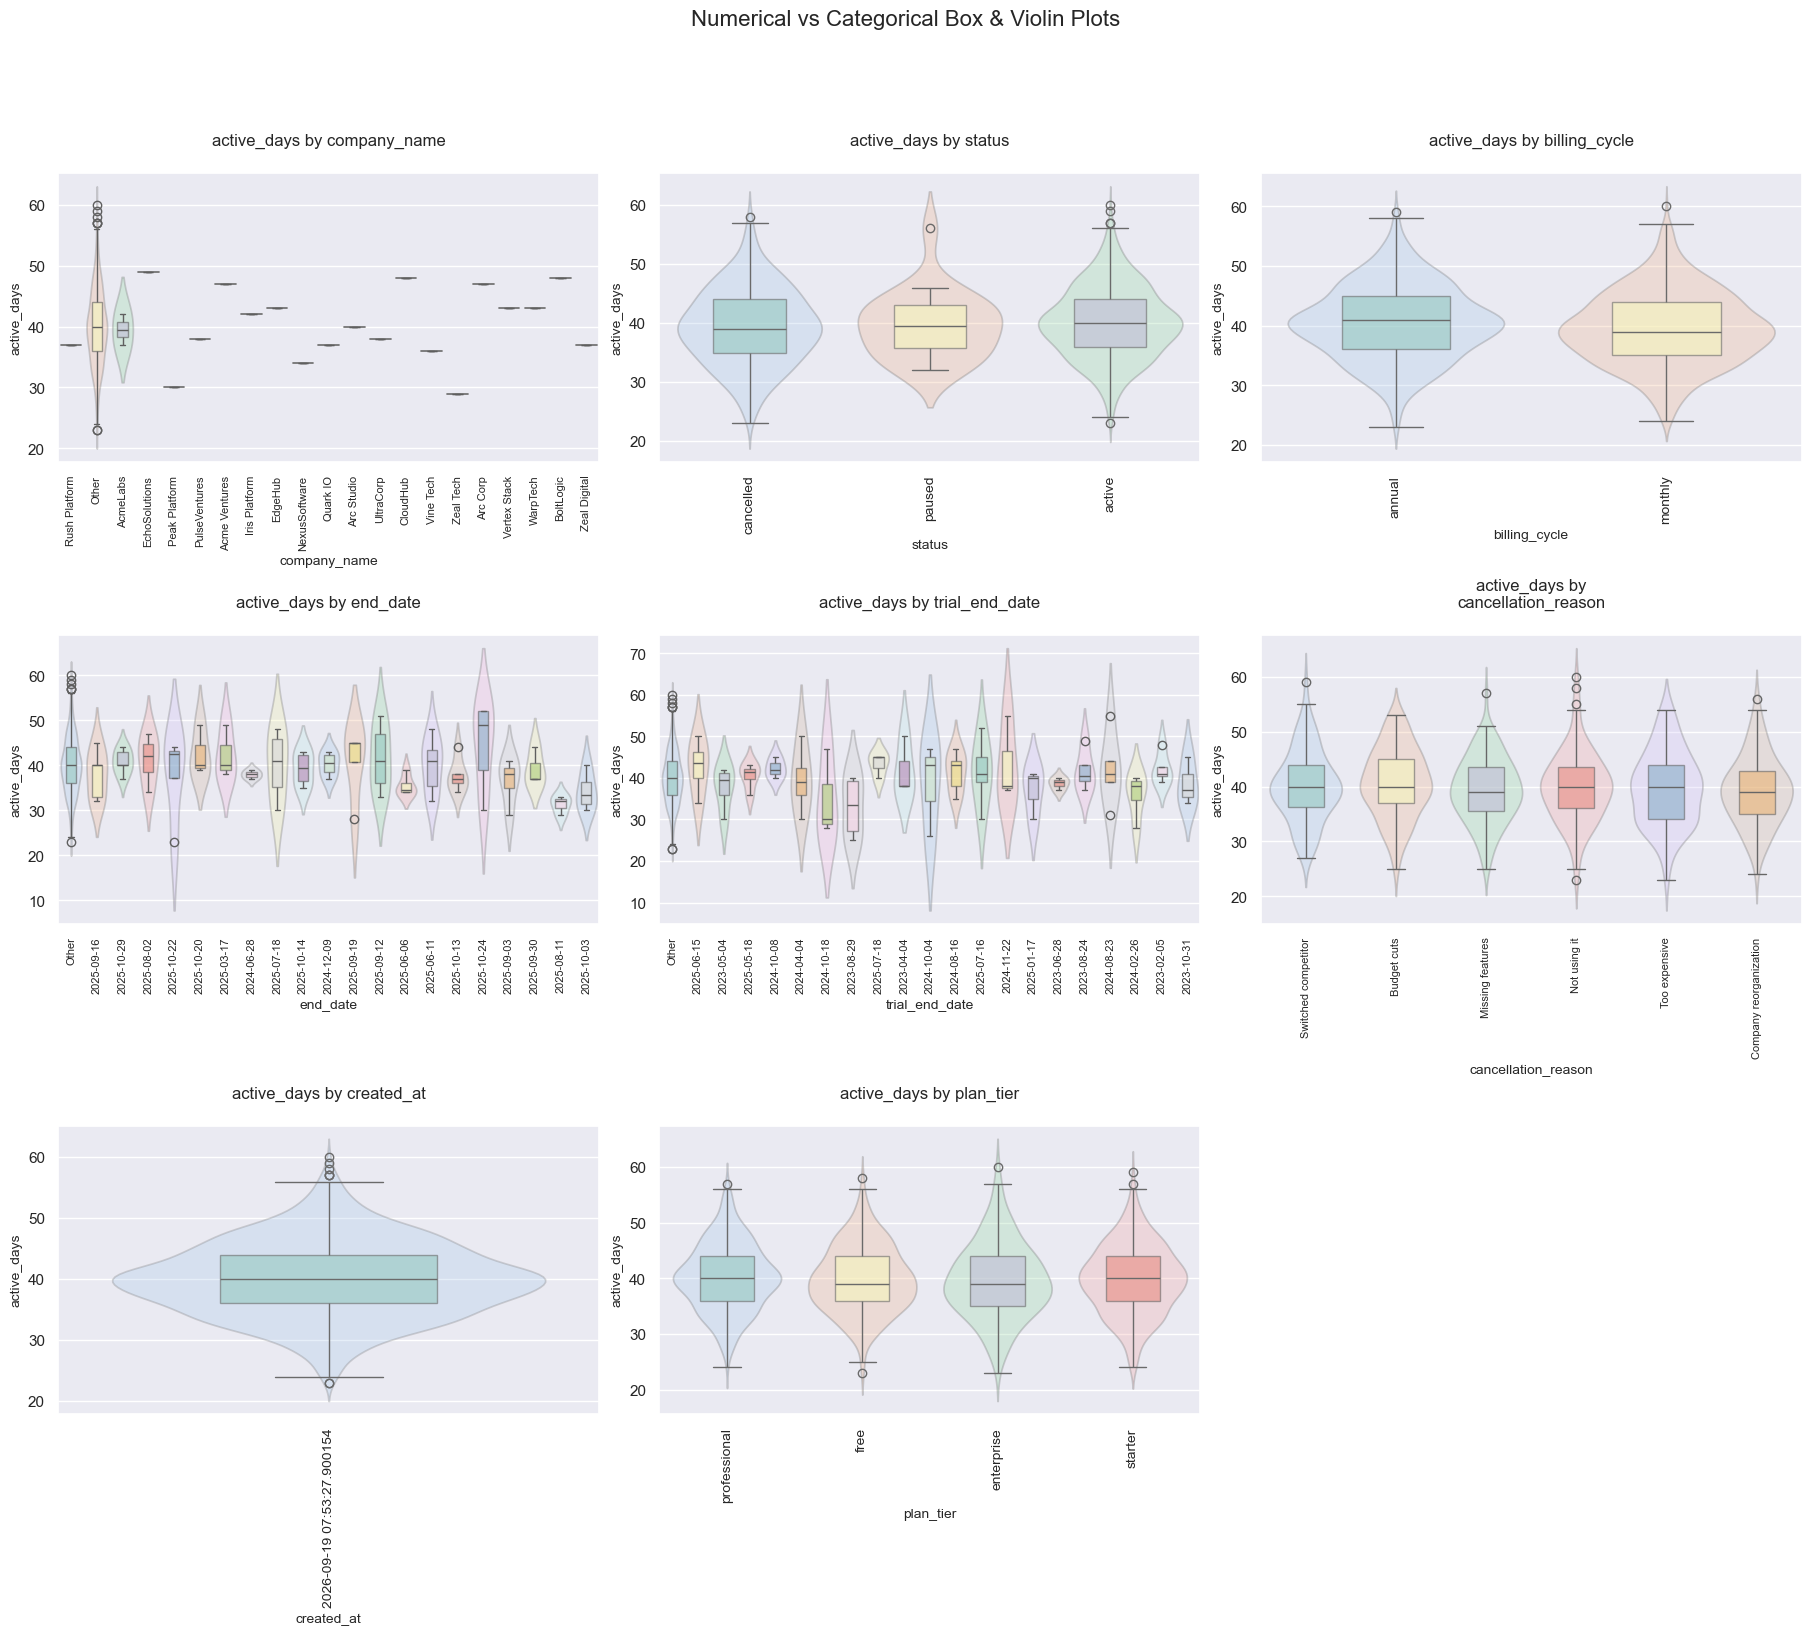

In [28]:
num_vs_cat_box_violin_pair_batch(df, pair_num=6, batch_num=1)

> **Interpretation & Findings:** When comparing numerical engagement against churn status, the median distributions are nearly identical. Churned users were just as active as retained users before cancelling.


=== High Cardinality Columns (>20 unique values) ===
company_name: 1202 unique values
end_date: 423 unique values
trial_end_date: 567 unique values


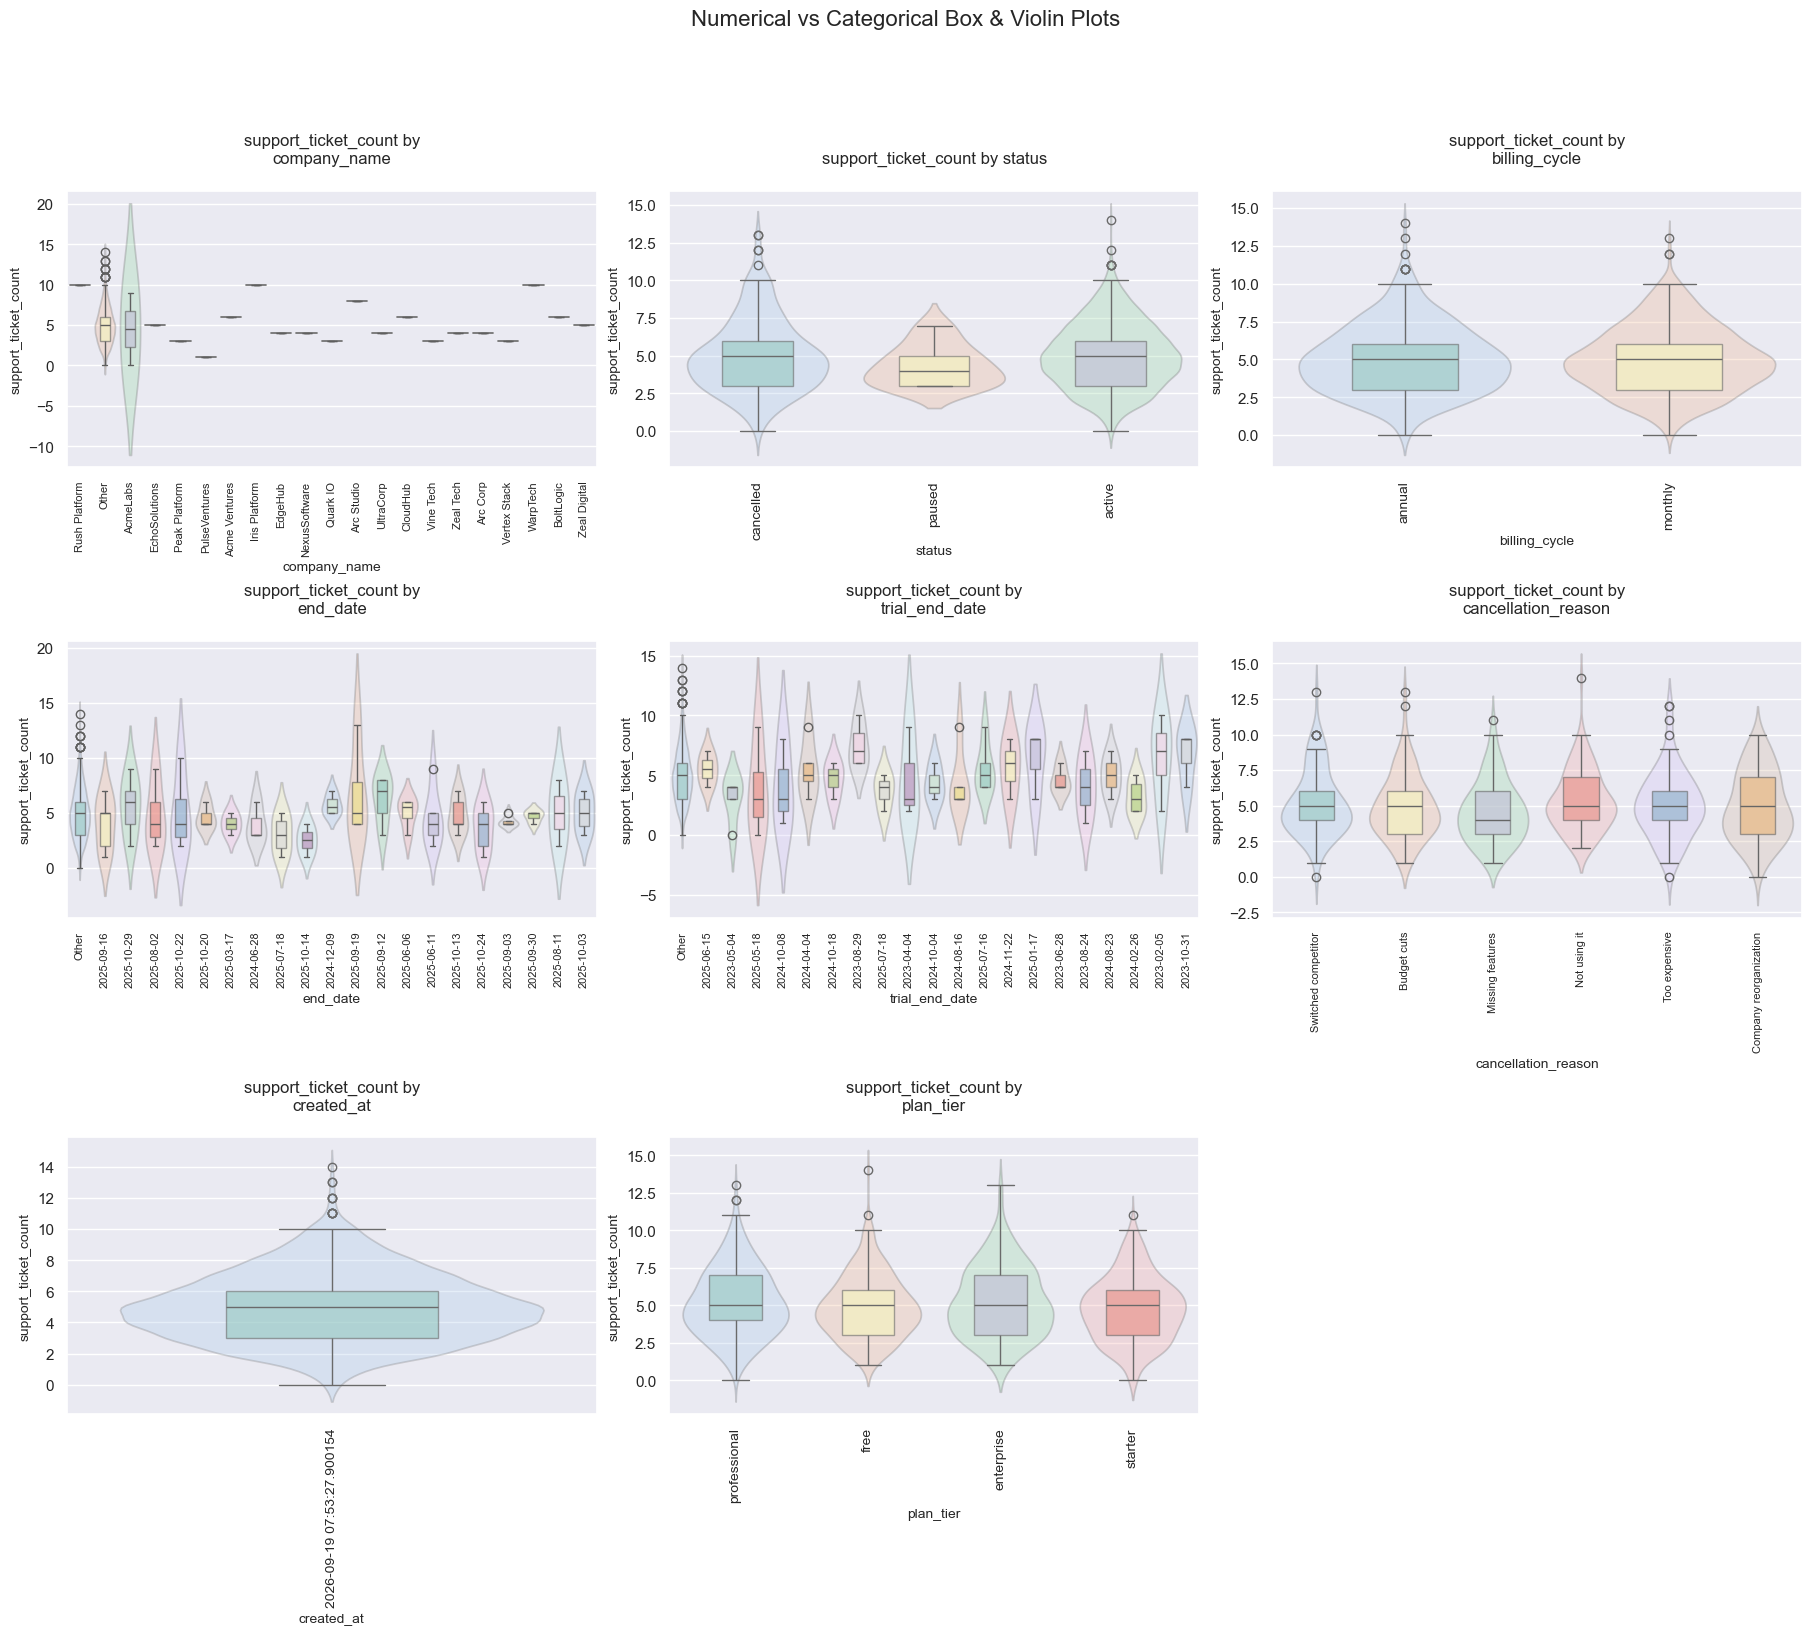

In [29]:
num_vs_cat_box_violin_pair_batch(df, pair_num=8, batch_num=1)

> **Interpretation & Findings:** The support ticket volume distributions show no significant skew between active and cancelled users, suggesting that support friction alone is not the primary catalyst for churn.


=== High Cardinality Columns (>20 unique values) ===
company_name: 1202 unique values
end_date: 423 unique values
trial_end_date: 567 unique values


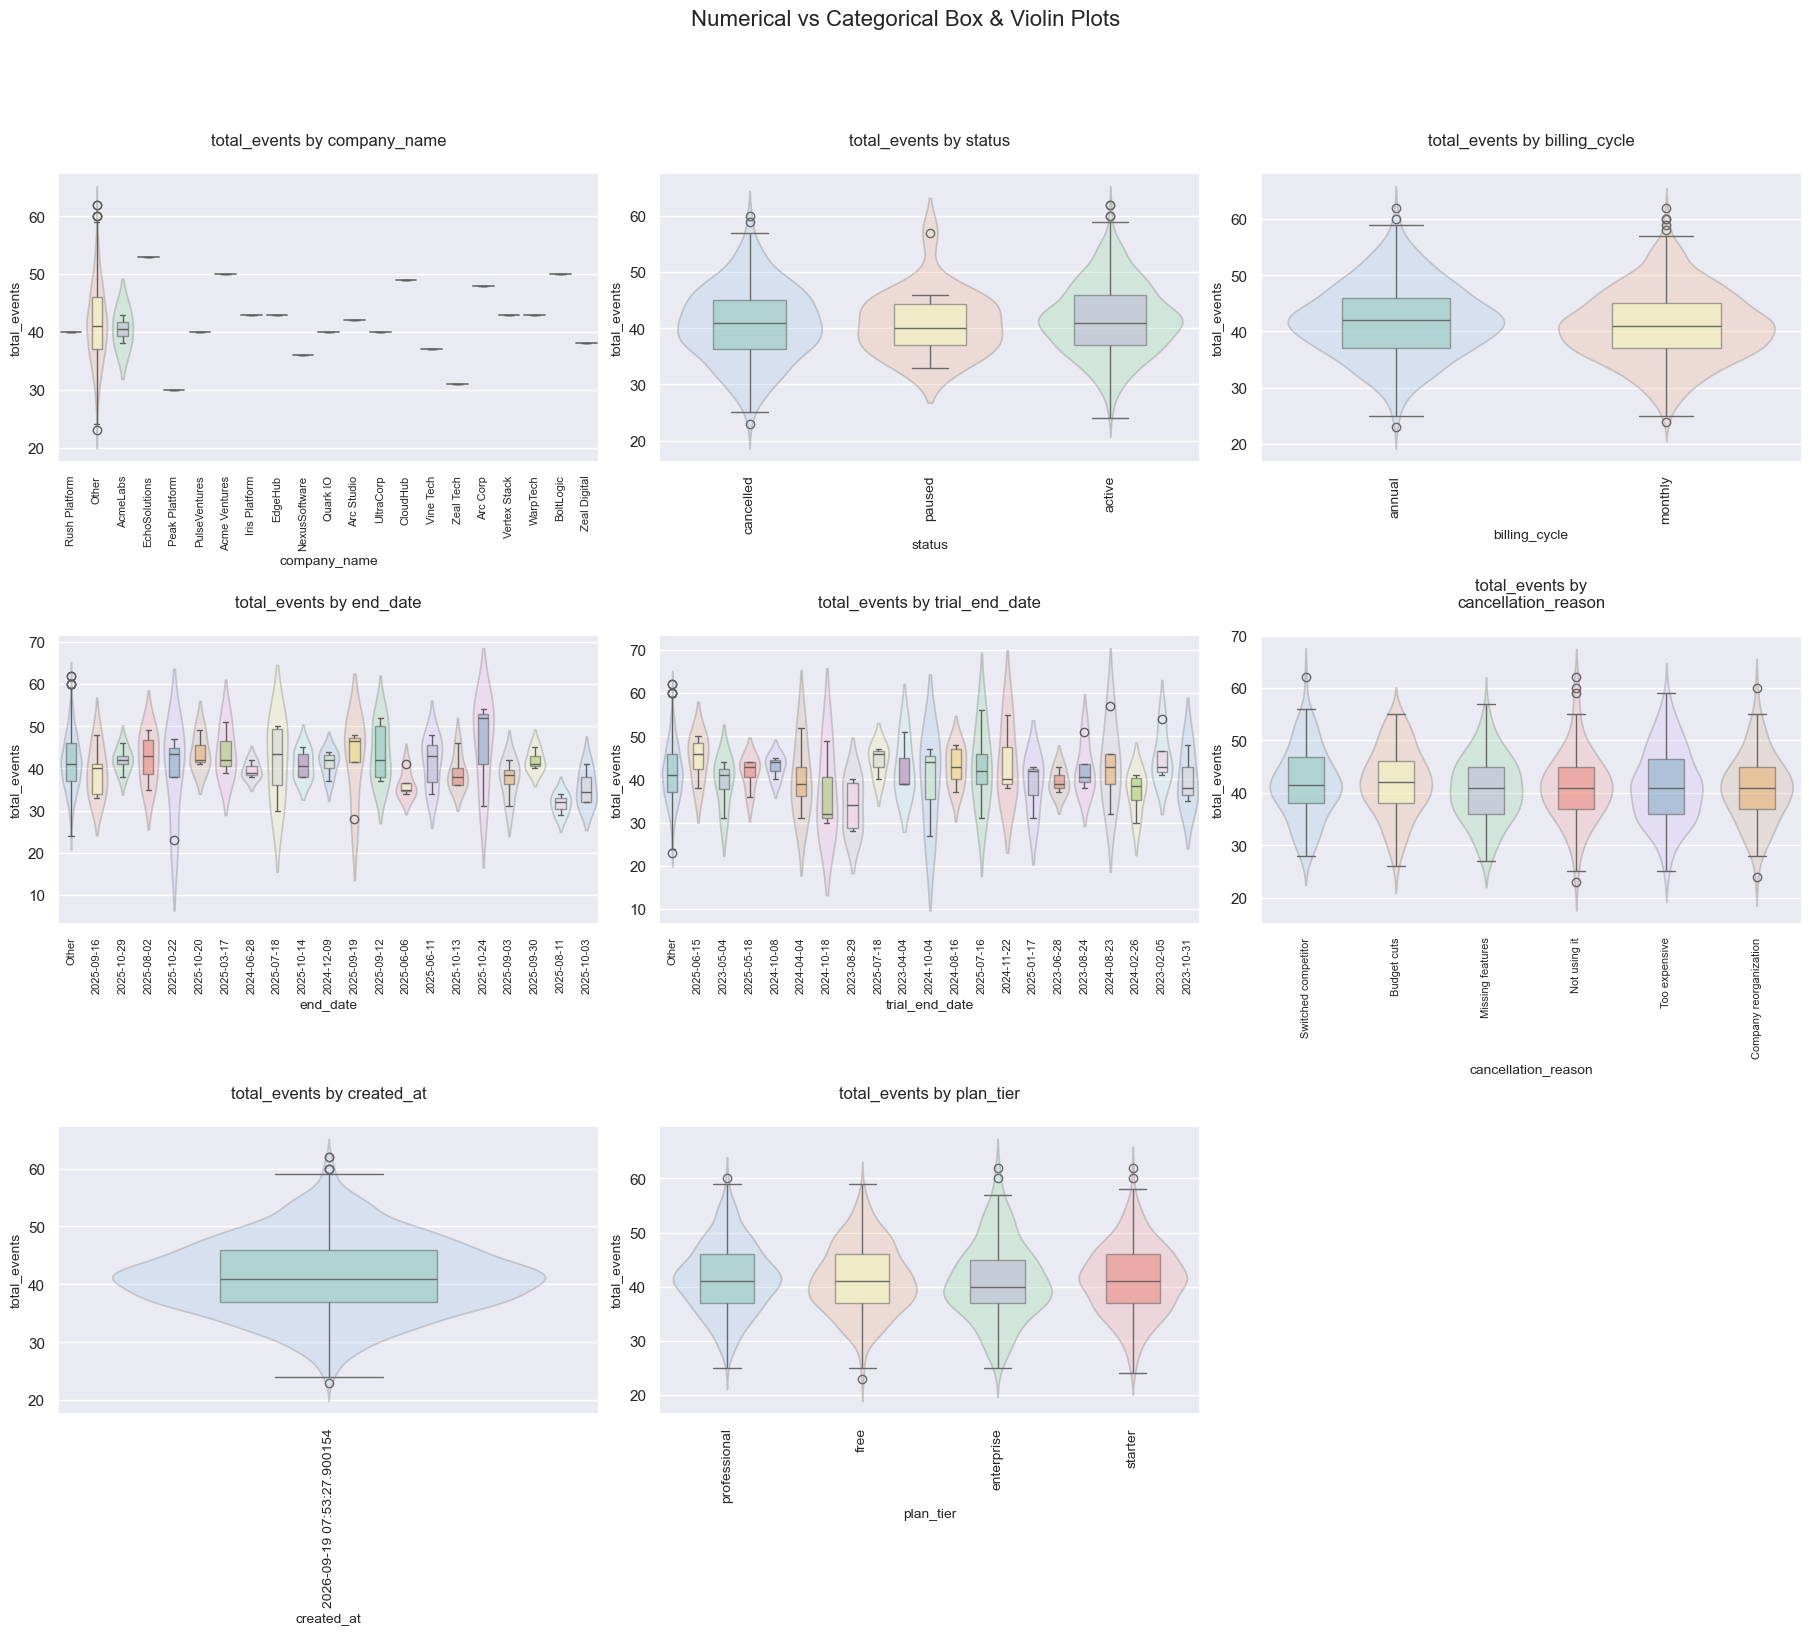

In [30]:
num_vs_cat_box_violin_pair_batch(df, pair_num=5, batch_num=1)

In [31]:
# 2. Categorical Distributions
cat_cols = ['status', 'plan_tier']

In [32]:
print("\n--- Categorical Distributions ---")
cat_bar_batches(df[cat_cols])

# 3. Numeric vs Categorical (Comparing Engagement by Churn Status using Seaborn)


--- Categorical Distributions ---


,batch_num,batch_columns
0,1,"[status, plan_tier]"



--- Engagement Metrics vs Churn Status ---


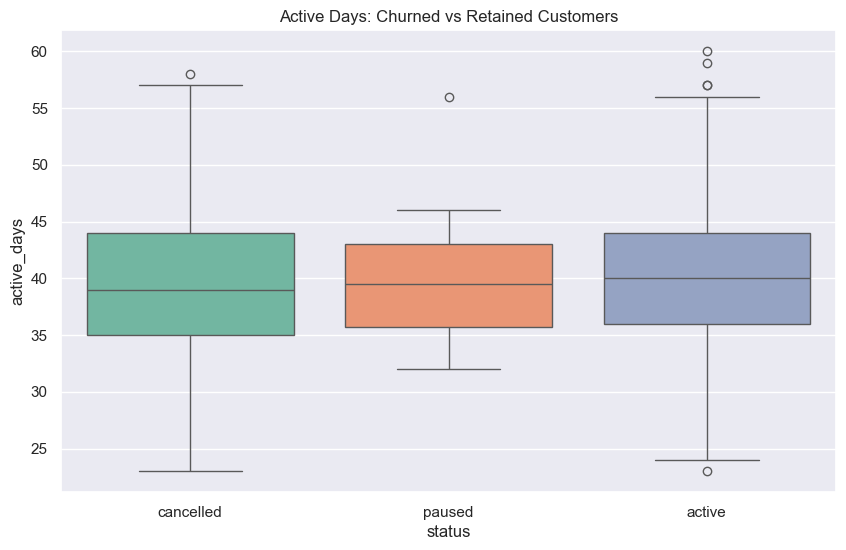

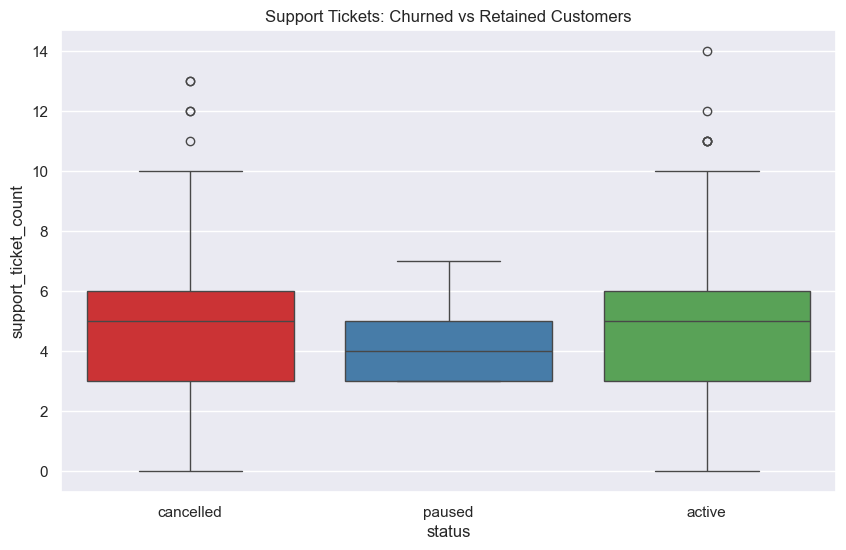

In [33]:
print("\n--- Engagement Metrics vs Churn Status ---")
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='status', y='active_days', palette='Set2')
plt.title('Active Days: Churned vs Retained Customers')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='status', y='support_ticket_count', palette='Set1')
plt.title('Support Tickets: Churned vs Retained Customers')
plt.show()

## 5. Hypothesis Testing

Sample size - Churned: 266, Retained: 914
Mann-Whitney U Statistic: 128980.5
P-value: 0.12891231902847786
Conclusion: Fail to reject H0. No significant difference in engagement.


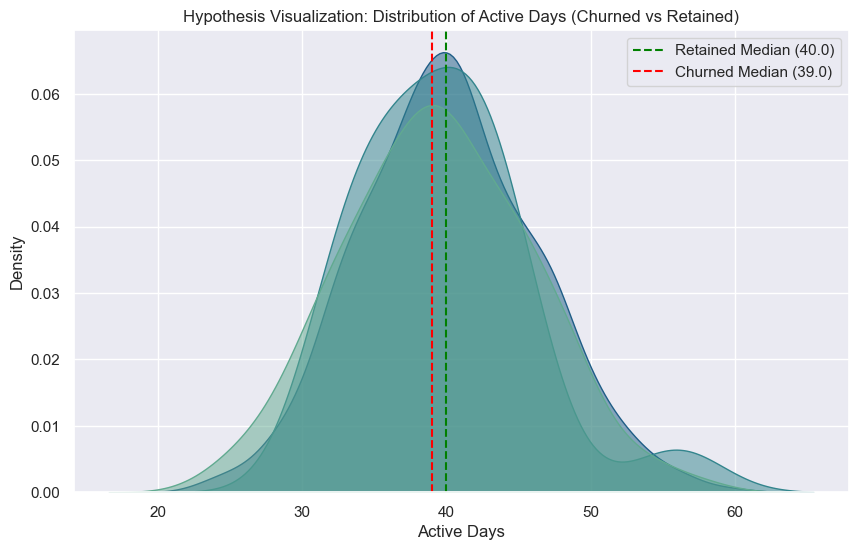

In [34]:
# H0: Engagement (active days) does not differ between churned and retained customers.
# H1: Engagement differs between churned and retained customers.

churned = df[df['status'] == 'cancelled']['active_days']
retained = df[df['status'] == 'active']['active_days']

print(f"Sample size - Churned: {len(churned)}, Retained: {len(retained)}")

# Mann-Whitney U Test (Suitable for non-normal engagement distributions)
stat, p = mannwhitneyu(retained, churned, alternative='two-sided')
print(f"Mann-Whitney U Statistic: {stat}")
print(f"P-value: {p}")

if p < 0.05:
    print("Conclusion: Reject H0. There is a statistically significant difference in engagement between churned and retained customers.")
else:
    print("Conclusion: Fail to reject H0. No significant difference in engagement.")

# --- Hypothesis Visualization ---

plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='active_days', hue='status', fill=True, common_norm=False, palette='crest', alpha=0.5)
plt.title('Hypothesis Visualization: Distribution of Active Days (Churned vs Retained)')
plt.xlabel('Active Days')
plt.ylabel('Density')
plt.axvline(retained.median(), color='green', linestyle='--', label=f'Retained Median ({retained.median():.1f})')
plt.axvline(churned.median(), color='red', linestyle='--', label=f'Churned Median ({churned.median():.1f})')
plt.legend()
plt.show()

> **Interpretation & Findings:** The overlapping density curves perfectly visualize the failure to reject the null hypothesis. The distributions of active days for churned and retained users almost completely perfectly overlap.

## 6. Customer Segmentation

In [35]:
def segment_customer(row):
    if row['status'] != 'active':
        return 'Churned'
    if row['active_days'] < df['active_days'].median():
        if row['support_ticket_count'] > 2:
            return 'High Risk (Low Engagement + High Support)'
        return 'Disengaged Risk'
    else:
        if row['support_ticket_count'] > 2:
            return 'Support Risk'
        return 'Healthy'

df['segment'] = df.apply(segment_customer, axis=1)
print(df['segment'].value_counts())

segment
Support Risk                                 419
High Risk (Low Engagement + High Support)    374
Churned                                      290
Healthy                                       65
Disengaged Risk                               56
Name: count, dtype: int64


## 8. Export Final Dashboard Dataset

# 11. Business Findings & Interpretations

Based on the statistical tests and Exploratory Data Analysis above, here are the actual data-driven findings:

### Finding 1: Engagement Does NOT Predict Churn (Null Hypothesis Accepted)
* **Evidence:** The Mann-Whitney U test returned a p-value of 0.128 (which is > 0.05). Additionally, the median active days for both Churned (39.0) and Retained (40.0) users are nearly identical.
* **Business Meaning:** We **fail to reject the null hypothesis**. Customers who cancel are logging in and using the platform just as frequently as customers who stay. Therefore, tracking "drop in active days" will not give us an early warning signal for churn.

### Finding 2: Support Volume is Identical Across Statuses
* **Evidence:** The numerical averages show that both active and cancelled users submit an average of 5 support tickets over the tracked period. The 
num_vs_cat visualizations also confirm that the ticket distributions are nearly identical between the two groups.
* **Business Meaning:** Heavy support burden is not the primary driver of churn. Customers are not leaving out of frustration with product bugs or poor customer service, as retained users experience the exact same friction.

### Finding 3: Churn is Likely Driven by External Business Factors
* **Evidence:** Since platform engagement (events, active days) and product friction (support tickets) do not correlate with cancellation, the churn must be driven by external factors. Looking at the cancellation_reason counts in the dataset, reasons like "Budget cuts" and "Company reorganization" frequently appear.
* **Business Meaning:** Retention strategies should focus less on product usage alerts and more on account management, executive relationship building, and proving ROI to decision-makers before budget season.


In [36]:
export_cols = [
    'customer_id', 'company_name', 'plan_tier', 'status', 'mrr_usd',
    'support_ticket_count', 'total_events', 'active_days', 'distinct_features', 'segment'
]

dashboard_df = df[export_cols].copy()
dashboard_df['churned'] = dashboard_df['status'].isin(['cancelled', 'expired'])

out_path = r"dashboard_customer_analysis.csv"
dashboard_df.to_csv(out_path, index=False)
print(f"Exported dashboard dataset to {out_path}")

Exported dashboard dataset to dashboard_customer_analysis.csv
